# Análisis FBG: 4 Sensores + Media Polarizaciones (11/02/2026, 15:00-17:30)

## 🔬 Contexto del Experimento

**Objetivo**: Estudio de **repetibilidad** de las medidas FBG. Este experimento replica las condiciones de las adquisiciones del **02/02/2026** y **04/02/2026**, con la fibra **desenrollada y vuelta a enrollar** para evaluar la reproducibilidad de los resultados.

**Comparación**: Los resultados se compararán con el notebook del **04/02/2026** (ver Sección 9) para validar la repetibilidad de las sensibilidades térmicas y de presión.

⚠️ **Incidencias durante la adquisición**:
- **Parón a mitad del experimento** por falta de espacio en disco
- **Poco nitrógeno disponible** al inicio de las medidas
- Estos factores pueden haber afectado la estabilidad de algunos plateaus

✅ **NOTA IMPORTANTE**: En esta adquisición se procesan los **4 sensores FBG** (FBG-1, FBG-2, FBG-3, FBG-4).
Se verificará si FBG-4 tiene datos válidos en este dataset.

Este notebook analiza **sensores FBG** (con 2 polarizaciones cada uno).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.


## 📋 Configuración:3. **Datos de presión**: ✅ En esta adquisición los datos de presión funcionan correctamente y se utilizan para definir los plateaus.

- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible (no solo 15:00-17:30), permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

- **4 FBGs**: FBG-1, FBG-2, FBG-3, FBG-4 (cada uno con polarización P y S)1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.

- **Análisis**: Media de polarizaciones vs temperatura y presión## 💡 Notas sobre el flujo de trabajo:

- **Plateaus**: Definición manual por presión
- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente en lxplus)

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Apr 17 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]


✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Desde lxplus puedes acceder directamente a /eos/ (montado localmente)
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260211.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:  # Menos de 1 KB es sospechoso
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")
    print(f"   Puede estar corrupto o vacío")

# Cargar datos del archivo ROOT
try:
    # Intentar abrir con diferentes opciones de compresión
    print("\n🔄 Intentando abrir archivo ROOT...")
    
    try:
        # Intento 1: Lectura normal
        file = uproot.open(filepath)
    except ValueError as e:
        if "unrecognized compression algorithm" in str(e):
            print(f"⚠️  Error de compresión detectado: {e}")
            print(f"🔄 Intentando lectura sin verificación de compresión...")
            
            # Intento 2: Con handler personalizado
            try:
                file = uproot.open(filepath, handler=uproot.source.file.MemmapSource)
            except:
                print(f"❌ No se pudo abrir el archivo con método alternativo")
                print(f"\n💡 POSIBLES CAUSAS:")
                print(f"   1. El archivo ROOT está corrupto")
                print(f"   2. El archivo se interrumpió durante la escritura")
                print(f"   3. Problemas de red durante la transferencia")
                print(f"   4. Versión incompatible del formato ROOT")
                print(f"\n🔧 SOLUCIONES SUGERIDAS:")
                print(f"   • Verifica que la adquisición se completó correctamente")
                print(f"   • Intenta volver a copiar el archivo desde la fuente original")
                print(f"   • Usa otro archivo ROOT de fecha cercana")
                print(f"   • Verifica el archivo con: rootls {filepath}")
                raise
        else:
            raise
    
    # Mostrar trees disponibles
    print(f"✓ Archivo abierto correctamente")
    print(f"✓ Trees disponibles: {file.keys()}")
    
    # Cargar datos de los trees disponibles
    peak_data = file["peak"].arrays(library="np")
    temp_data = file["temp"].arrays(library="np")
    press_data = file["press"].arrays(library="np")
    
    # 🔍 DIAGNÓSTICO: Ver estructura de peak_data
    print(f"\n🔍 Claves en peak_data: {list(peak_data.keys())}")
    for key in peak_data.keys():
        print(f"   {key}: shape = {peak_data[key].shape}")
    
    # Extraer arrays de datos
    times_peak_raw = peak_data["t"][:, 0]  # Tiempos de wavelength
    times_temp_raw = temp_data["t"]  # Tiempos de temperatura
    
    # IMPORTANTE: Convertir wavelength de metros a nanómetros
    wav_raw = peak_data["wav"] * 1e9  # m -> nm
    
    temp_raw = temp_data["temp"]
    press_raw = press_data["press"]
    
    print(f"\n✅ Datos cargados correctamente")
    print(f"   • Wavelength: {wav_raw.shape}")
    print(f"   • Wavelength range: [{np.min(wav_raw[wav_raw > 0]):.2f}, {np.max(wav_raw):.2f}] nm")
    print(f"   • Temperature: {temp_raw.shape}")
    print(f"   • Pressure: {press_raw.shape}")
    
    # Convertir tiempos a datetime SIN aplicar shift aún
    times_peak_original = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_peak_raw])
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_temp_raw])
    
    # DIAGNÓSTICO: Mostrar rangos SIN SHIFT para comparar
    print(f"\n📅 RANGOS TEMPORALES ORIGINALES (sin shift):")
    print(f"=" * 70)
    print(f"🔵 WAVELENGTH (picos):")
    print(f"   Inicio: {times_peak_original[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_peak_original[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"\n🔴 TEMPERATURA:")
    print(f"   Inicio: {times_temp[0].strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"   Fin:    {times_temp[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Calcular diferencia temporal
    diff_inicio = (times_temp[0] - times_peak_original[0]).total_seconds() / 3600
    diff_fin = (times_temp[-1] - times_peak_original[-1]).total_seconds() / 3600
    
    print(f"\n⚠️  DESFASE DETECTADO:")
    print(f"   Temperatura START - Wavelength START: {diff_inicio:+.2f} horas")
    print(f"   Temperatura END - Wavelength END: {diff_fin:+.2f} horas")
    
    if abs(diff_inicio) > 0.5 or abs(diff_fin) > 0.5:
        print(f"\n💡 RECOMENDACIÓN:")
        print(f"   Los datos parecen tener un desfase temporal.")
        if diff_inicio > 0:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours={abs(diff_inicio):.0f})")
        else:
            print(f"   Prueba: TIME_SHIFT = datetime.timedelta(hours=-{abs(diff_inicio):.0f})")
        print(f"   Luego re-ejecuta esta celda.")
    else:
        print(f"\n✅ Los datos están alineados temporalmente (no necesitas TIME_SHIFT)")
    
    # Aplicar TIME_SHIFT a wavelength
    times_peak = times_peak_original + TIME_SHIFT
    
    # Variable unificada para compatibilidad con el resto del código
    times_raw = times_peak_raw  # Mantener raw para referencia
    times_all = times_peak  # Times con shift aplicado
    
    if TIME_SHIFT.total_seconds() != 0:
        print(f"\n✅ TIME_SHIFT aplicado: {TIME_SHIFT.total_seconds()/3600:.1f}h")
        print(f"   Nuevo rango wavelength:")
        print(f"   Inicio: {times_peak[0].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"   Fin:    {times_peak[-1].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    print(f"\n💡 Verifica que el archivo existe en /eos/")
    raise
except Exception as e:
    print(f"❌ ERROR al cargar el archivo: {e}")
    print(f"\n🔍 Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

📂 Cargando archivo ROOT: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260211.root
⏱️  TIME_SHIFT configurado: 2.0 horas
📊 Tamaño del archivo: 81.30 MB

🔄 Intentando abrir archivo ROOT...
✓ Archivo abierto correctamente
✓ Trees disponibles: ['peak;5', 'press;3', 'temp;3']

🔍 Claves en peak_data: ['t', 'wav', 'sweep', 'ch', 'pos']
   t: shape = (1276750, 2)
   wav: shape = (1276750, 2, 4)
   sweep: shape = (1276750, 2, 4)
   ch: shape = (1276750, 4)
   pos: shape = (1276750, 4)

✅ Datos cargados correctamente
   • Wavelength: (1276750, 2, 4)
   • Wavelength range: [1543.02, 1560.48] nm
   • Temperature: (4909, 8)
   • Pressure: (11012, 1)

📅 RANGOS TEMPORALES ORIGINALES (sin shift):
🔵 WAVELENGTH (picos):
   Inicio: 2026-02-11 13:23:00
   Fin:    2026-02-11 16:13:21

🔴 TEMPERATURA:
   Inicio: 2026-02-11 15:22:04
   Fin:    2026-02-11 18:08:14

⚠️  DESFASE DETECTADO:
   Temperatura START - Wavelength START: +1.98 horas
   Temperatura END - Wavelength END: +1.91 horas

💡 RECOMEND

### 📊 Visualización de Presión y Temperatura

✅ **En esta adquisición los datos de presión funcionan correctamente**. Este plot muestra la evolución de presión y temperatura durante el experimento.

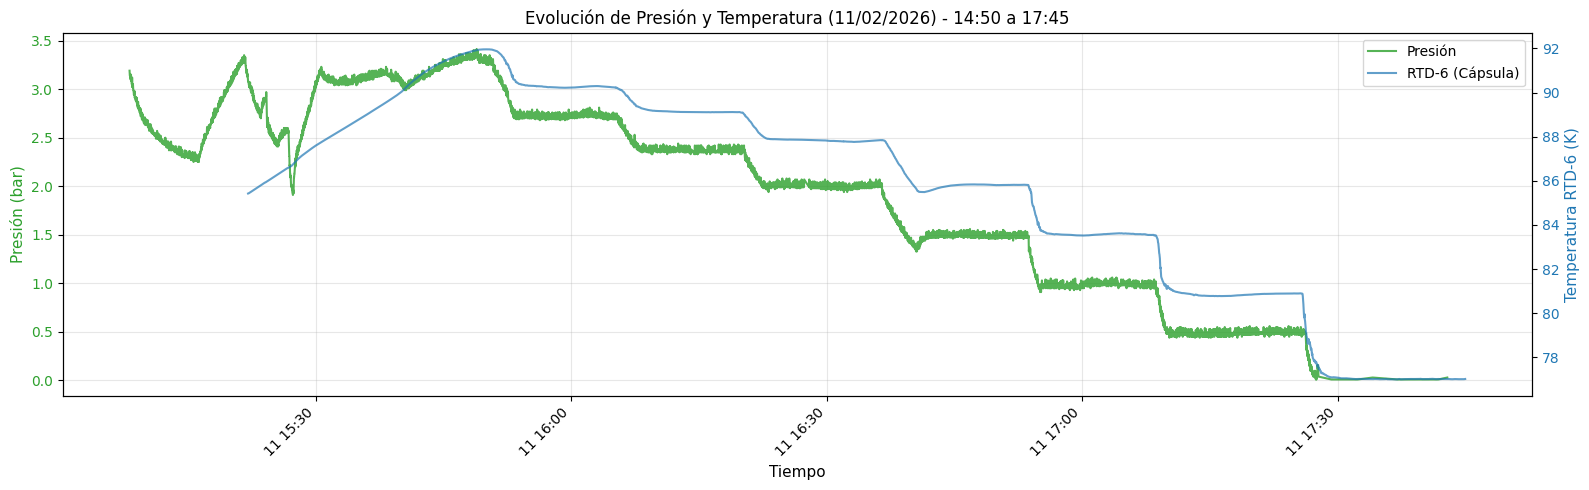


📊 Rango temporal mostrado: 14:50 - 17:45

📊 Estadísticas de presión:
   Rango: [0.01, 3.41] bar
   Media: 2.02 bar
   Std: 0.911 bar
   Puntos válidos: 8,277

📊 Estadísticas de temperatura (RTD-6):
   Rango: [76.99, 91.96] K
   Media: 85.59 K
   Std: 4.531 K
   Puntos válidos: 4,215


In [4]:
# Plot de presión y temperatura superpuestos
fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# ============================================================================
# RANGO TEMPORAL PARA VISUALIZACIÓN
# ============================================================================
fecha_plot = datetime.date(2026, 2, 11)
t_plot_inicio_press = datetime.datetime.combine(fecha_plot, datetime.time(14, 50))
t_plot_fin_press = datetime.datetime.combine(fecha_plot, datetime.time(17, 45))

# Extraer tiempos de presión y datos
times_press_raw = press_data["t"]
times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_press_raw])

# Verificar dimensiones de press_raw y seleccionar primer sensor si es necesario
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]  # Usar primer sensor de presión
else:
    press_data_plot = press_raw

# Filtrar valores positivos Y por rango temporal
press_valid_mask = (press_data_plot > 0) & (times_press >= t_plot_inicio_press) & (times_press <= t_plot_fin_press)
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

# Temperatura (RTD-6 - cápsula fibra)
rtd_ref_idx_preview = 6
temp_preview = temp_raw[:, rtd_ref_idx_preview]
mask_temp_valid = (temp_preview > 0) & (times_temp >= t_plot_inicio_press) & (times_temp <= t_plot_fin_press)
times_temp_valid = times_temp[mask_temp_valid]
temp_valid = temp_preview[mask_temp_valid]

# Eje izquierdo: Presión
color_press = 'tab:green'
ax1.set_xlabel('Tiempo', fontsize=11)
ax1.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
if len(press_valid) > 0:
    ax1.plot(times_press_valid, press_valid, color=color_press, linewidth=1.5, alpha=0.8, label='Presión')
    ax1.tick_params(axis='y', labelcolor=color_press)
else:
    print("⚠️ No hay datos válidos de presión")

# Eje derecho: Temperatura
ax2 = ax1.twinx()
color_temp = 'tab:blue'
ax2.set_ylabel('Temperatura RTD-6 (K)', fontsize=11, color=color_temp)
if len(temp_valid) > 0:
    ax2.plot(times_temp_valid, temp_valid, color=color_temp, linewidth=1.5, alpha=0.7, label='RTD-6 (Cápsula)')
    ax2.tick_params(axis='y', labelcolor=color_temp)

# Título y grid
ax1.set_title(f'Evolución de Presión y Temperatura (11/02/2026) - {t_plot_inicio_press.strftime("%H:%M")} a {t_plot_fin_press.strftime("%H:%M")}', fontsize=12)
ax1.grid(True, alpha=0.3)

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# Rotar etiquetas del eje X
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {t_plot_inicio_press.strftime('%H:%M')} - {t_plot_fin_press.strftime('%H:%M')}")

if len(press_valid) > 0:
    print(f"\n📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}] bar")
    print(f"   Media: {np.mean(press_valid):.2f} bar")
    print(f"   Std: {np.std(press_valid):.3f} bar")
    print(f"   Puntos válidos: {len(press_valid):,}")

if len(temp_valid) > 0:
    print(f"\n📊 Estadísticas de temperatura (RTD-6):")
    print(f"   Rango: [{np.min(temp_valid):.2f}, {np.max(temp_valid):.2f}] K")
    print(f"   Media: {np.mean(temp_valid):.2f} K")
    print(f"   Std: {np.std(temp_valid):.3f} K")
    print(f"   Puntos válidos: {len(temp_valid):,}")

## 3️⃣ Filtrar Rango Temporal (15:00-17:30)

In [5]:
# Usar times_all que ya incluye el TIME_SHIFT aplicado
times = times_all  # Ya tiene el shift de 2h aplicado

print(f"📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):")
print(f"   Inicio: {times[0].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Fin:    {times[-1].strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
# Opción A: Usar TODO el rango disponible
use_full_range = False  # Cambiar a True para analizar todos los datos

if use_full_range:
    t_inicio = times[0]
    t_fin = times[-1]
else:
    # Opción B: Definir rango específico manualmente
    # ⚠️ AJUSTA ESTOS VALORES según el rango que viste arriba
    fecha = datetime.date(2026, 2, 11)  # ⬅️ CAMBIAR según tu archivo (20260211.root)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(14, 50))
    t_fin = datetime.datetime.combine(fecha, datetime.time(17, 45))

# Filtrar wavelength por rango temporal (ya tiene shift aplicado)
mask_time = (times >= t_inicio) & (times <= t_fin)
times_filtered = times[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura usando sus propios tiempos (sin shift)
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

# Filtrar presión usando sus propios tiempos
mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
press_filtered = press_data_plot[mask_time_press]
times_press_filtered = times_press[mask_time_press]

print(f"\n✅ Rango seleccionado para análisis:")
print(f"   {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos wavelength en el rango: {len(times_filtered):,}")
print(f"   Puntos temperatura en el rango: {len(times_temp_filtered):,}")
print(f"   Puntos presión en el rango: {len(times_press_filtered):,}")

if len(times_filtered) == 0:
    print(f"\n⚠️ ADVERTENCIA: No hay datos en el rango especificado!")
    print(f"\n💡 Soluciones:")
    print(f"   1. Cambia 'use_full_range = True' para usar todos los datos")
    print(f"   2. O ajusta 't_inicio' y 't_fin' según el rango disponible (ver arriba)")

📅 Rango COMPLETO de datos disponible (wavelength con TIME_SHIFT aplicado):
   Inicio: 2026-02-11 15:23:00
   Fin:    2026-02-11 18:13:21

✅ Rango seleccionado para análisis:
   2026-02-11 14:50 - 17:45
   Puntos wavelength en el rango: 1,064,022
   Puntos temperatura en el rango: 4,215
   Puntos presión en el rango: 9,297


## 4️⃣ Análisis de Temperatura (8 RTDs)

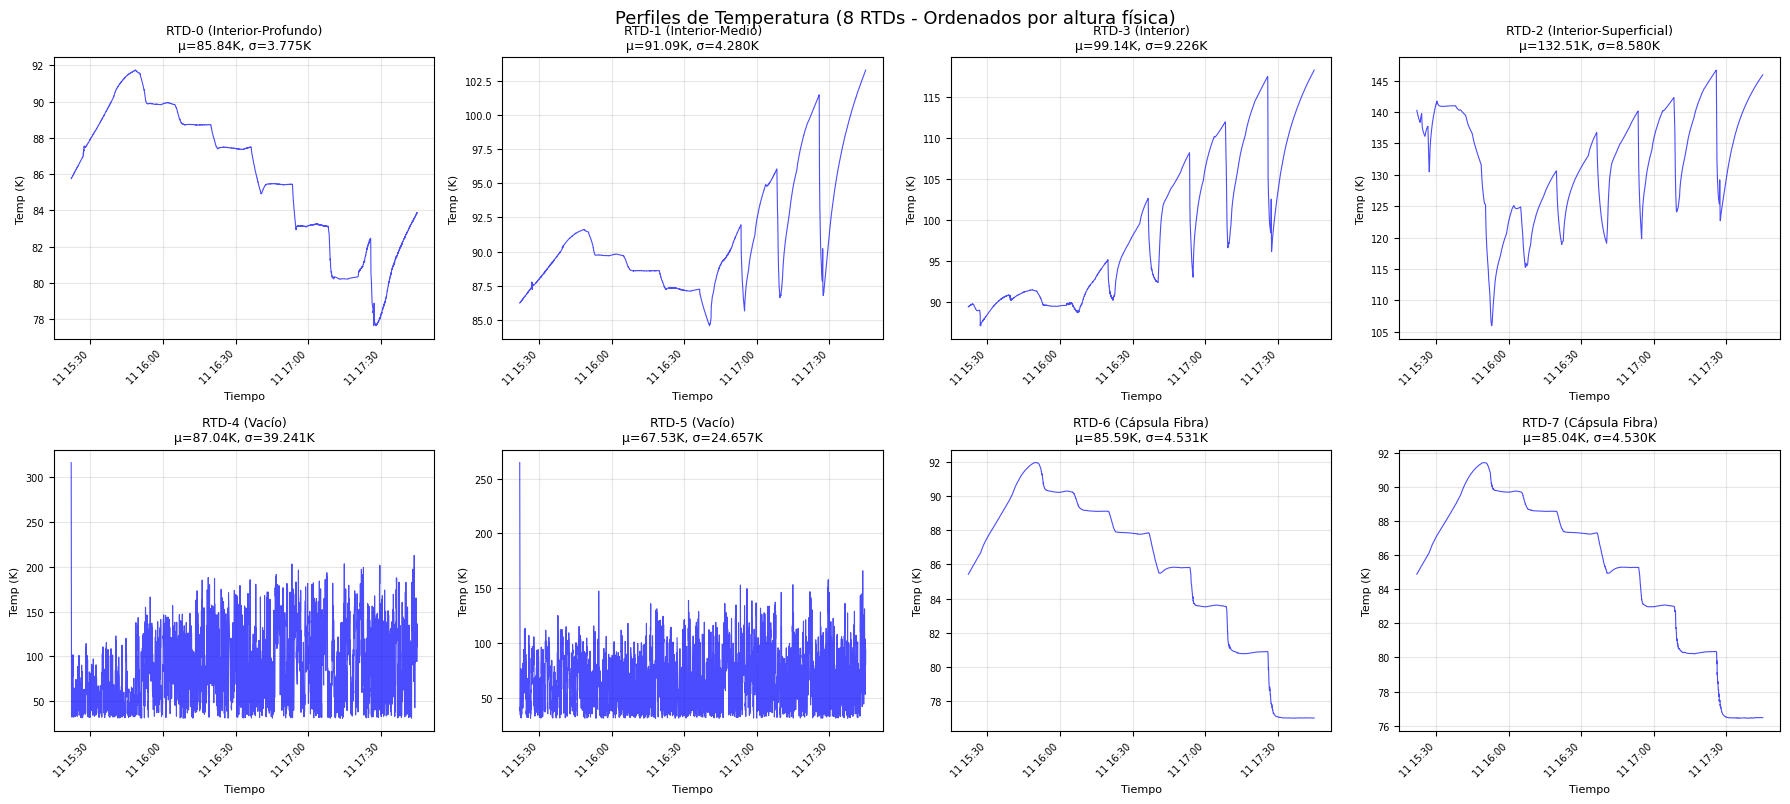


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ= 85.84K  σ= 3.775K
RTD-1 (Interior-Medio)        : μ= 91.09K  σ= 4.280K
RTD-3 (Interior)              : μ= 99.14K  σ= 9.226K
RTD-2 (Interior-Superficial)  : μ=132.51K  σ= 8.580K
RTD-4 (Vacío)                 : μ= 87.04K  σ=39.241K
RTD-5 (Vacío)                 : μ= 67.53K  σ=24.657K
RTD-6 (Cápsula Fibra)         : μ= 85.59K  σ= 4.531K
RTD-7 (Cápsula Fibra)         : μ= 85.04K  σ= 4.530K


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [7]:
# ✅ CONFIGURACIÓN: 4 sensores FBG completos
# 4 sensores × 2 polarizaciones = 8 canales
# Índices 0-based: sensor 0, 1, 2, 3 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    {"pol": 0, "sensor": 3, "label": "FBG-4-P"},
    {"pol": 1, "sensor": 3, "label": "FBG-4-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (4 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si FBG-4 tiene datos válidos en este dataset")

✅ Configurados 8 canales FBG (4 sensores × 2 polarizaciones)
💡 Se verificará si FBG-4 tiene datos válidos en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (todos los sensores: 0, 1, 2, 3)
print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):")
for sensor_idx in range(4):  # 0, 1, 2, 3 (incluye FBG-4)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar todos los canales configurados (incluye FBG-4)
# 🔧 CONFIGURACIÓN: Elige el método de filtrado
USE_ROBUST_FILTERING = True  # True = MAD robusto, False = μ±3σ clásico
SIGMA_THRESHOLD = 3.0  # Ajusta este valor si quieres filtrado más o menos estricto (2.5-4.0)

print(f"\n⚙️  Método de filtrado: {'ROBUSTO (MAD)' if USE_ROBUST_FILTERING else 'CLÁSICO (μ±3σ)'}")
print(f"⚙️  Threshold: ±{SIGMA_THRESHOLD}{'×MAD' if USE_ROBUST_FILTERING else 'σ'}")

fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(
        wav_data, times_filtered, 
        sigma_threshold=SIGMA_THRESHOLD,
        use_robust=USE_ROBUST_FILTERING
    )

print("\n✅ Filtrado completado (4 sensores procesados)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (1064022, 2, 4)
   Dimensiones: (time=1064022, pol=2, sensor=4)

🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):
   FBG-1-P: 1064022 pts > 0, range=[1543.02, 1543.10] nm, μ=1543.07 nm
   FBG-1-S: 1064022 pts > 0, range=[1543.02, 1543.09] nm, μ=1543.06 nm
   FBG-2-P: 1064022 pts > 0, range=[1548.08, 1548.80] nm, μ=1548.61 nm
   FBG-2-S: 1064022 pts > 0, range=[1548.15, 1548.80] nm, μ=1548.77 nm
   FBG-3-P: 1064022 pts > 0, range=[1554.59, 1554.67] nm, μ=1554.64 nm
   FBG-3-S: 1064022 pts > 0, range=[1554.60, 1554.67] nm, μ=1554.64 nm
   FBG-4-P: 1064022 pts > 0, range=[1560.40, 1560.48] nm, μ=1560.45 nm
   FBG-4-S: 1064022 pts > 0, range=[1560.40, 1560.47] nm, μ=1560.44 nm

⚙️  Método de filtrado: ROBUSTO (MAD)
⚙️  Threshold: ±3.0×MAD

✅ Filtrado completado (4 sensores procesados)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      1543.065229  0.024184     1064022
FBG-1-S      1543.063796  0.017803     1064022
FBG-2-P      1548.7680

### 5.3 Calcular Media de Polarizaciones

In [9]:
# Calcular media P+S para cada sensor (4 sensores: 1, 2, 3, 4)
fbg_mean_data = {}

for sensor_num in [1, 2, 3, 4]:  # Todos los sensores (incluye FBG-4)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1543.064513     0.020903        1064022
FBG-2-Mean      1548.769812     0.018787        813755
FBG-3-Mean      1554.637357     0.020807        1064022
FBG-4-Mean      1560.443007     0.020739        1064022


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

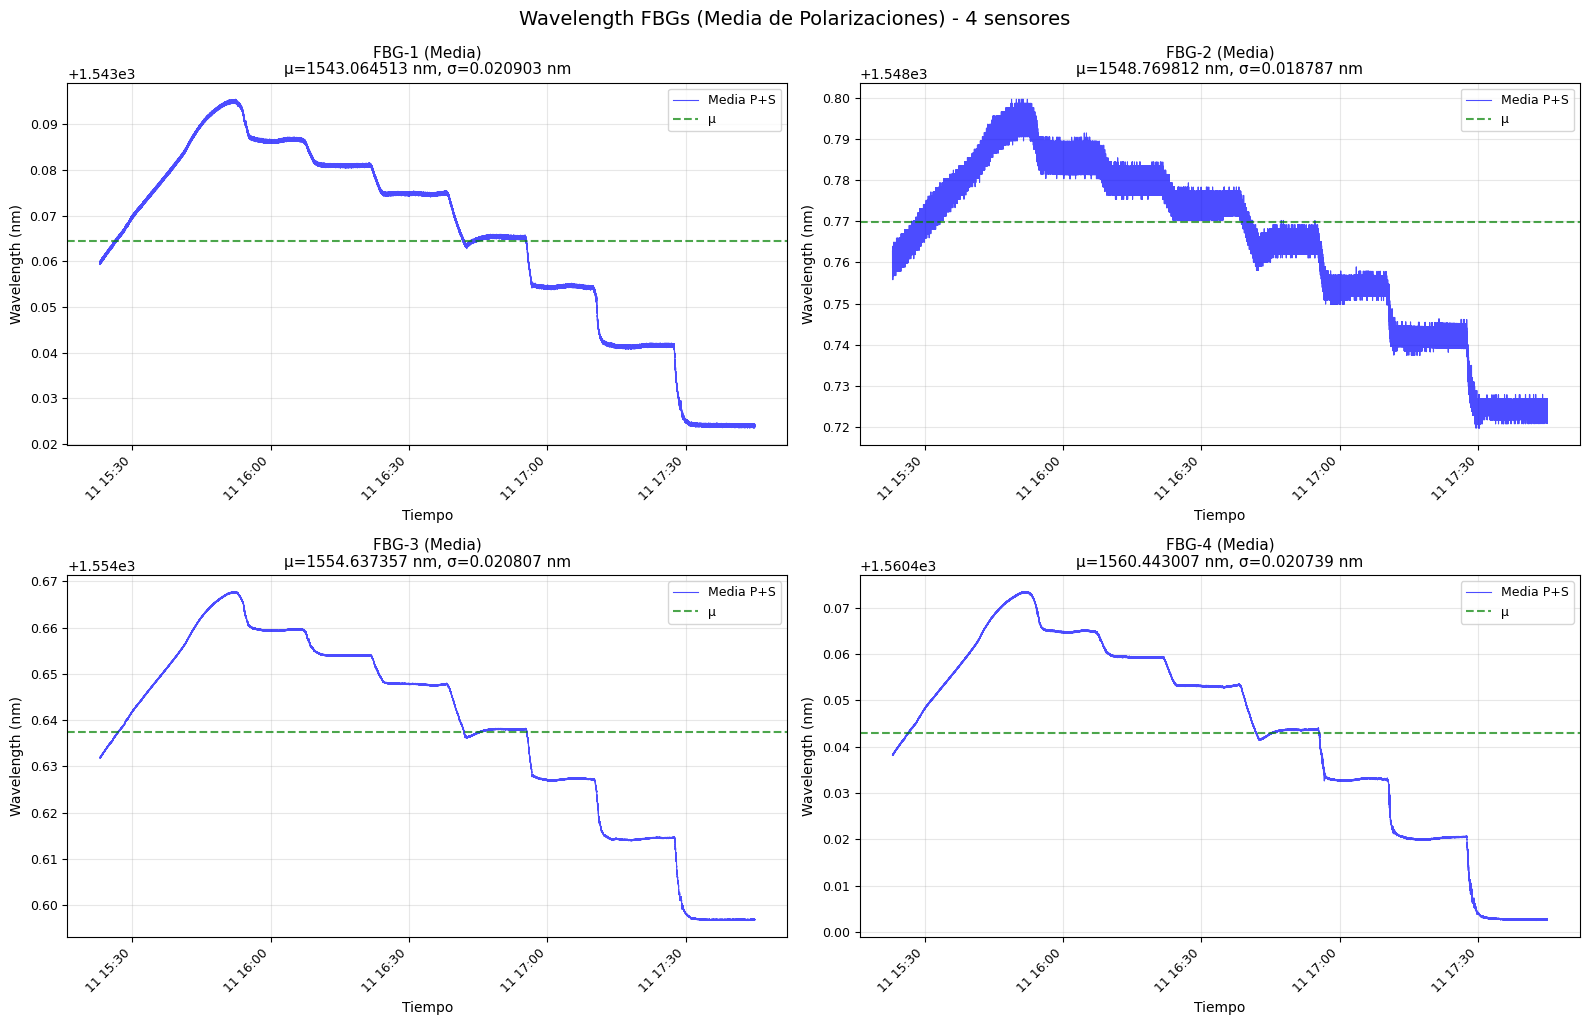

💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales


In [10]:
# Ajustar layout para 4 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=14, y=1.02)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales")

## 6️⃣ Correlación Temperatura/Presión - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [11]:
# Usar RTD-6 (cápsula fibra) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-6 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

# Presión válida en el rango filtrado
press_valid_filtered_mask = press_filtered > 0
times_press_ref = times_press_filtered[press_valid_filtered_mask]
press_ref_valid = press_filtered[press_valid_filtered_mask]

print(f"✅ Referencia temperatura: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")
print(f"\n✅ Presión:")
print(f"   Rango: [{np.min(press_ref_valid):.2f}, {np.max(press_ref_valid):.2f}] bar")

✅ Referencia temperatura: RTD-6 (Cápsula)
   Rango: [76.99, 91.96] K

✅ Presión:
   Rango: [0.01, 3.41] bar


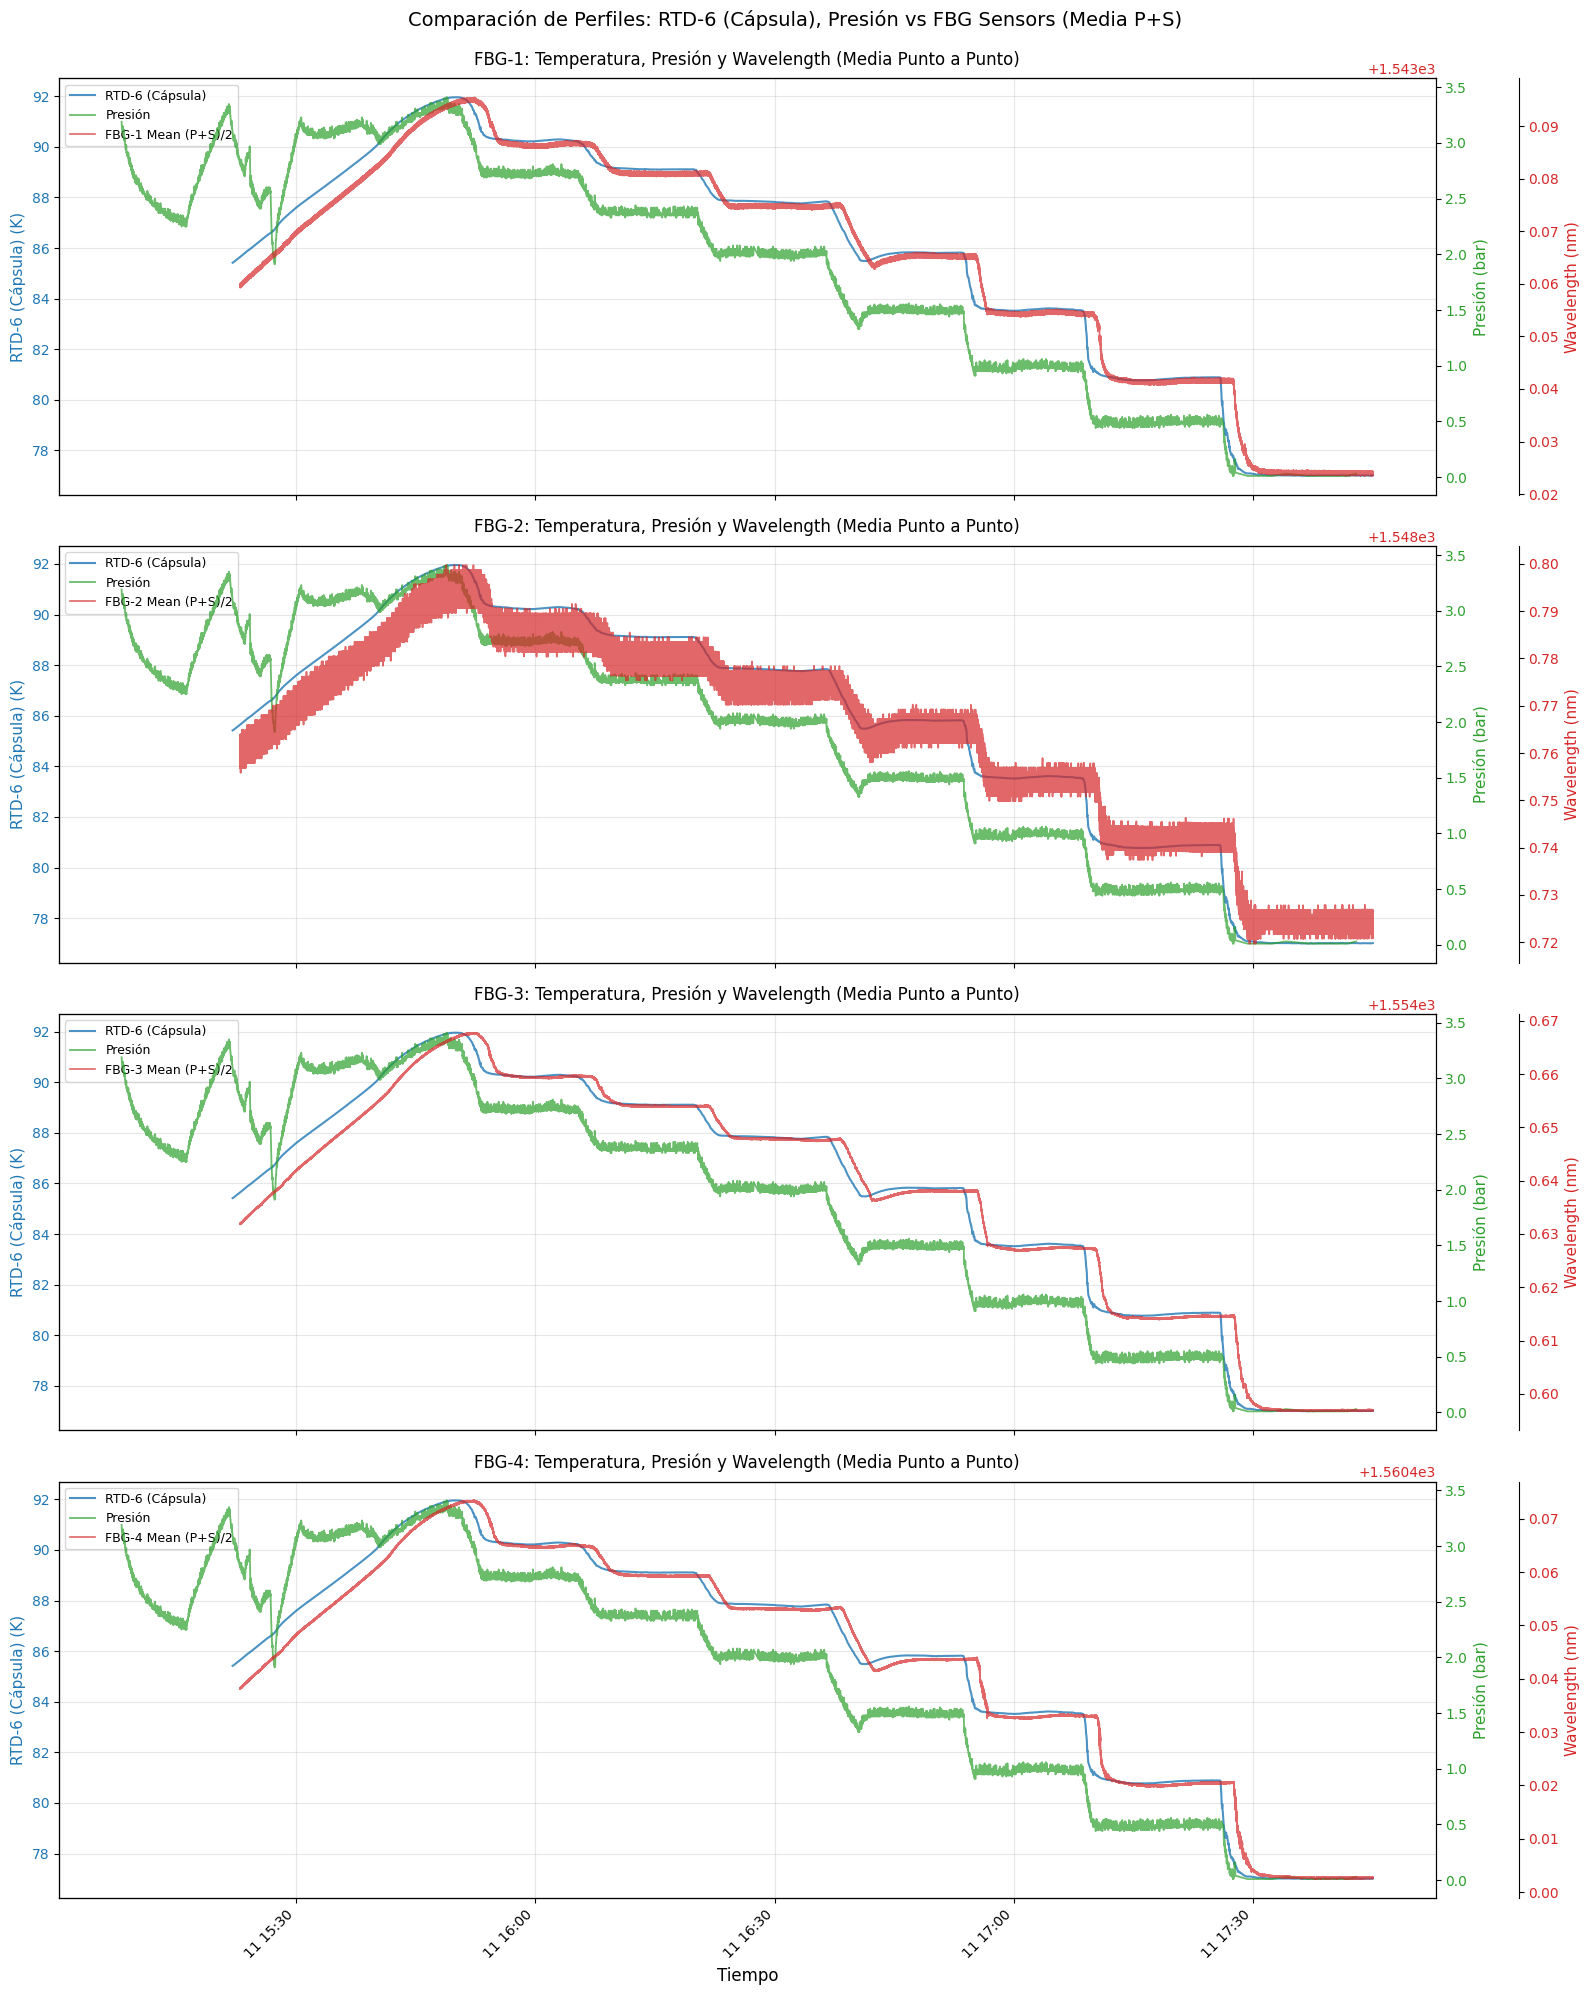

✅ Gráficos superpuestos generados para 4 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [12]:
# Superposición de temperatura, presión y wavelength (subplots para cada FBG)
n_sensors_plot = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_plot, 1, figsize=(16, 5*n_sensors_plot), sharex=True)

# Asegurar que axes sea un array
if n_sensors_plot == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_press = 'tab:green'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3, 4][:n_sensors_plot]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho 1: Presión
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 0))
    ax2.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
    ax2.plot(times_press_ref, press_ref_valid, color=color_press, linewidth=1.3, alpha=0.7, label='Presión')
    ax2.tick_params(axis='y', labelcolor=color_press)
    
    # Eje derecho 2: Wavelength (media punto a punto P+S)
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax3.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax3.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + lines3 + custom_lines, 
                  labels1 + labels2 + labels3 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura, Presión y Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name}, Presión vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para {n_sensors_plot} sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura, presión y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

Plateaus basados en niveles de presión (11/02/2026):
- **15:53h**: Primer plateau a 2.75 bar en equilibrio
- **16:09h**: Bajo a 2.4 bar
- **16:23h**: Bajo a 2.03 bar
- **16:36h**: Bajo a 1.5 bar (se estabiliza a 1.52 bar)
- **16:54h**: Bajo a 1 bar
- **17:10h**: Plateau adicional

Los intervalos definidos son conservadores (3-4 min después del cambio, terminan antes del siguiente) para asegurar estabilidad.

In [13]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en niveles de presión)
# ============================================================================
# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]

manual_plateaus = [
    ("Plateau 1 (2.75 bar)", "15:58", "16:05"),  # Fin: 16:06 → 16:05 (-1 min)
    ("Plateau 2 (2.4 bar)", "16:13", "16:20"),   # Fin: 16:21 → 16:20 (-1 min)
    ("Plateau 3 (2.0 bar)", "16:27", "16:35"),   # Sin cambios
    ("Plateau 4 (1.5 bar)", "16:46", "16:52"),   # Inicio: 16:39 → 16:44 (+5 min)
    ("Plateau 5 (1.0 bar)", "17:00", "17:07"),   # Fin: 17:10 → 17:05 (-5 min)
    ("Plateau 6", "17:15", "17:24"),
    ("Plateau 7", "17:35", "17:40"),# Inicio: 17:10 → 17:15 (+5 min), Fin: 17:20 → 17:22 (+2 min)
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*80)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        # Calcular media y std de presión en el plateau
        mask_press_plateau = (times_press_ref >= t0) & (times_press_ref <= tfin)
        press_plateau = press_ref_valid[mask_press_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            # Calcular media y std de presión (datos siempre disponibles en esta adquisición)
            if len(press_plateau) > 0:
                press_mean = np.mean(press_plateau)
                press_std = np.std(press_plateau)
            else:
                # Si no hay datos de presión en este rango, usar NaN
                press_mean = np.nan
                press_std = np.nan
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "press_mean": press_mean,
                "press_std": press_std,
                "n_temp_points": len(temp_plateau),
                "n_press_points": len(press_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
            print(f"  Presión:     μ={press_mean:.3f}bar, σ={press_std:.4f}bar, n={len(press_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*80)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1 (2.75 bar): 15:58 - 16:05
  Temperatura: μ=90.252K, σ=0.0264K, n=211
  Presión:     μ=2.722bar, σ=0.0243bar, n=417
Plateau 2 (2.4 bar): 16:13 - 16:20
  Temperatura: μ=89.111K, σ=0.0046K, n=208
  Presión:     μ=2.367bar, σ=0.0221bar, n=418
Plateau 3 (2.0 bar): 16:27 - 16:35
  Temperatura: μ=87.802K, σ=0.0266K, n=218
  Presión:     μ=1.993bar, σ=0.0234bar, n=443
Plateau 4 (1.5 bar): 16:46 - 16:52
  Temperatura: μ=85.821K, σ=0.0106K, n=181
  Presión:     μ=1.488bar, σ=0.0217bar, n=358
Plateau 5 (1.0 bar): 17:00 - 17:07
  Temperatura: μ=83.579K, σ=0.0296K, n=210
  Presión:     μ=0.993bar, σ=0.0221bar, n=418
Plateau 6: 17:15 - 17:24
  Temperatura: μ=80.830K, σ=0.0431K, n=270
  Presión:     μ=0.490bar, σ=0.0237bar, n=537
Plateau 7: 17:35 - 17:40
  Temperatura: μ=77.008K, σ=0.0057K, n=149
  Presión:     μ=0.010bar, σ=0.0000bar, n=2

✅ 7 plateaus definidos


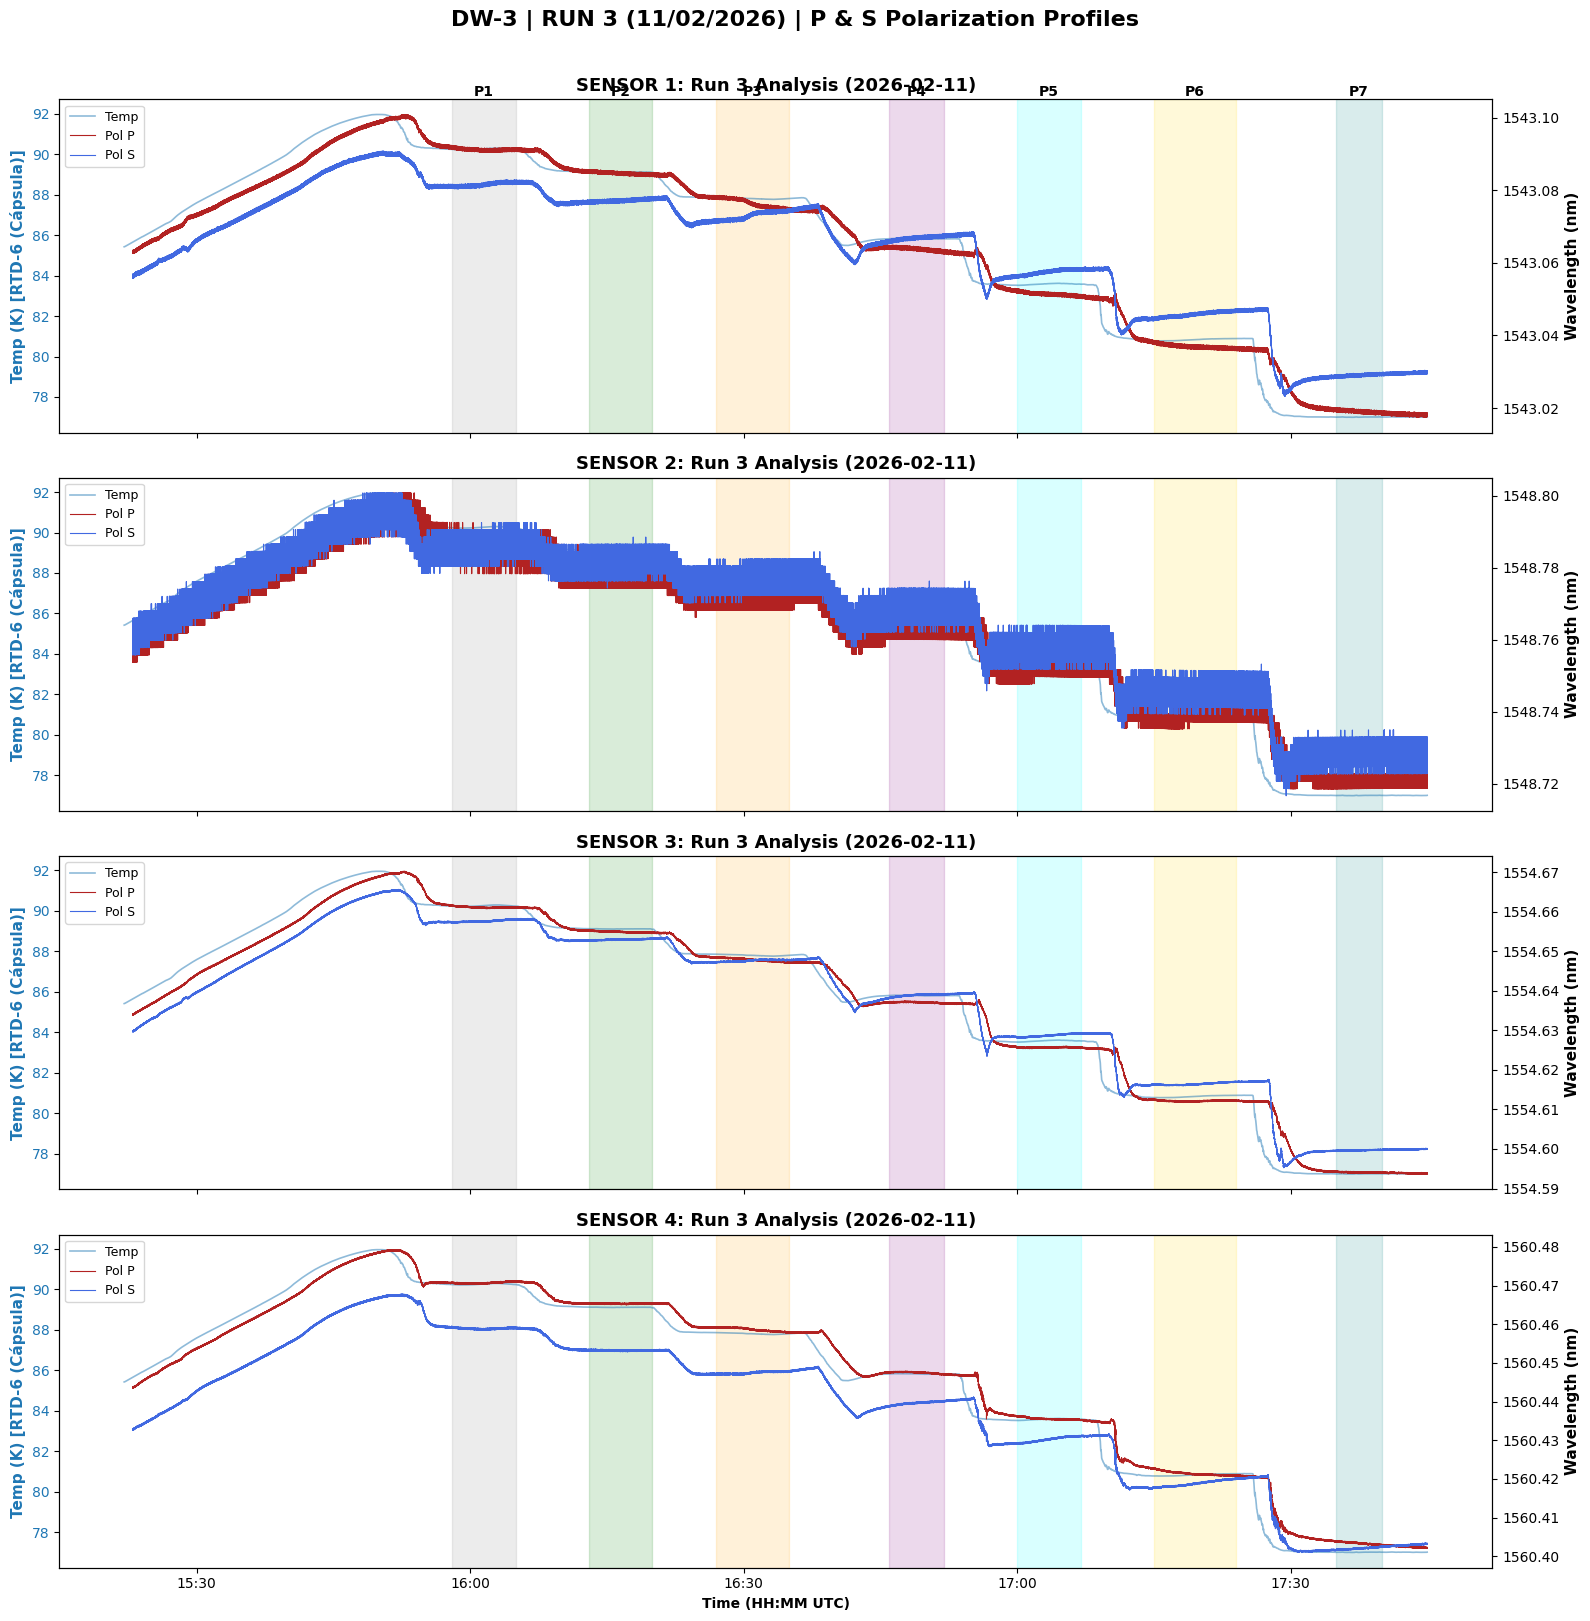

In [14]:
# ============================================================================
# PLOT 1 (RUN 3 - 11/02): Wavelength (P & S) vs Temperature with Shaded Plateaus
# Fiber: DW-3 (Ormocer-T) | 4 Sensors | Date: 2026-02-11
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   
color_pol_s = 'royalblue'   
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan', 'gold', 'teal']

# Explicitly including all 4 sensors for Run 3
sensors_to_plot = [1, 2, 3, 4] 
fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(16, 4 * len(sensors_to_plot)), sharex=True)

for idx, sensor_num in enumerate(sensors_to_plot):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    
    if label_p not in fbg_filtered_data:
        print(f"⚠️ Sensor {sensor_num} not found in data, skipping...")
        continue
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel(f'Temp (K) [{rtd_ref_name}]', fontsize=11, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.2, alpha=0.5, label='Temp')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.15)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', ha='center', va='bottom', fontweight='bold')

    # 3. Right Axis: Wavelengths
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, fontweight='bold')
    ax2.plot(data_p["timestamps"], data_p["wavelength"], color=color_pol_p, linewidth=0.8, label='Pol P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"], color=color_pol_s, linewidth=0.8, label='Pol S')
    ax2.ticklabel_format(useOffset=False, axis='y')
    
    ax1.set_title(f'SENSOR {sensor_num}: Run 3 Analysis (2026-02-11)', fontsize=13, fontweight='bold')
    # Combine legends
    l1, lb1 = ax1.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lb1 + lb2, loc='upper left', fontsize=9)

axes[-1].set_xlabel('Time (HH:MM UTC)', fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.suptitle(f'DW-3 | RUN 3 (11/02/2026) | P & S Polarization Profiles', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

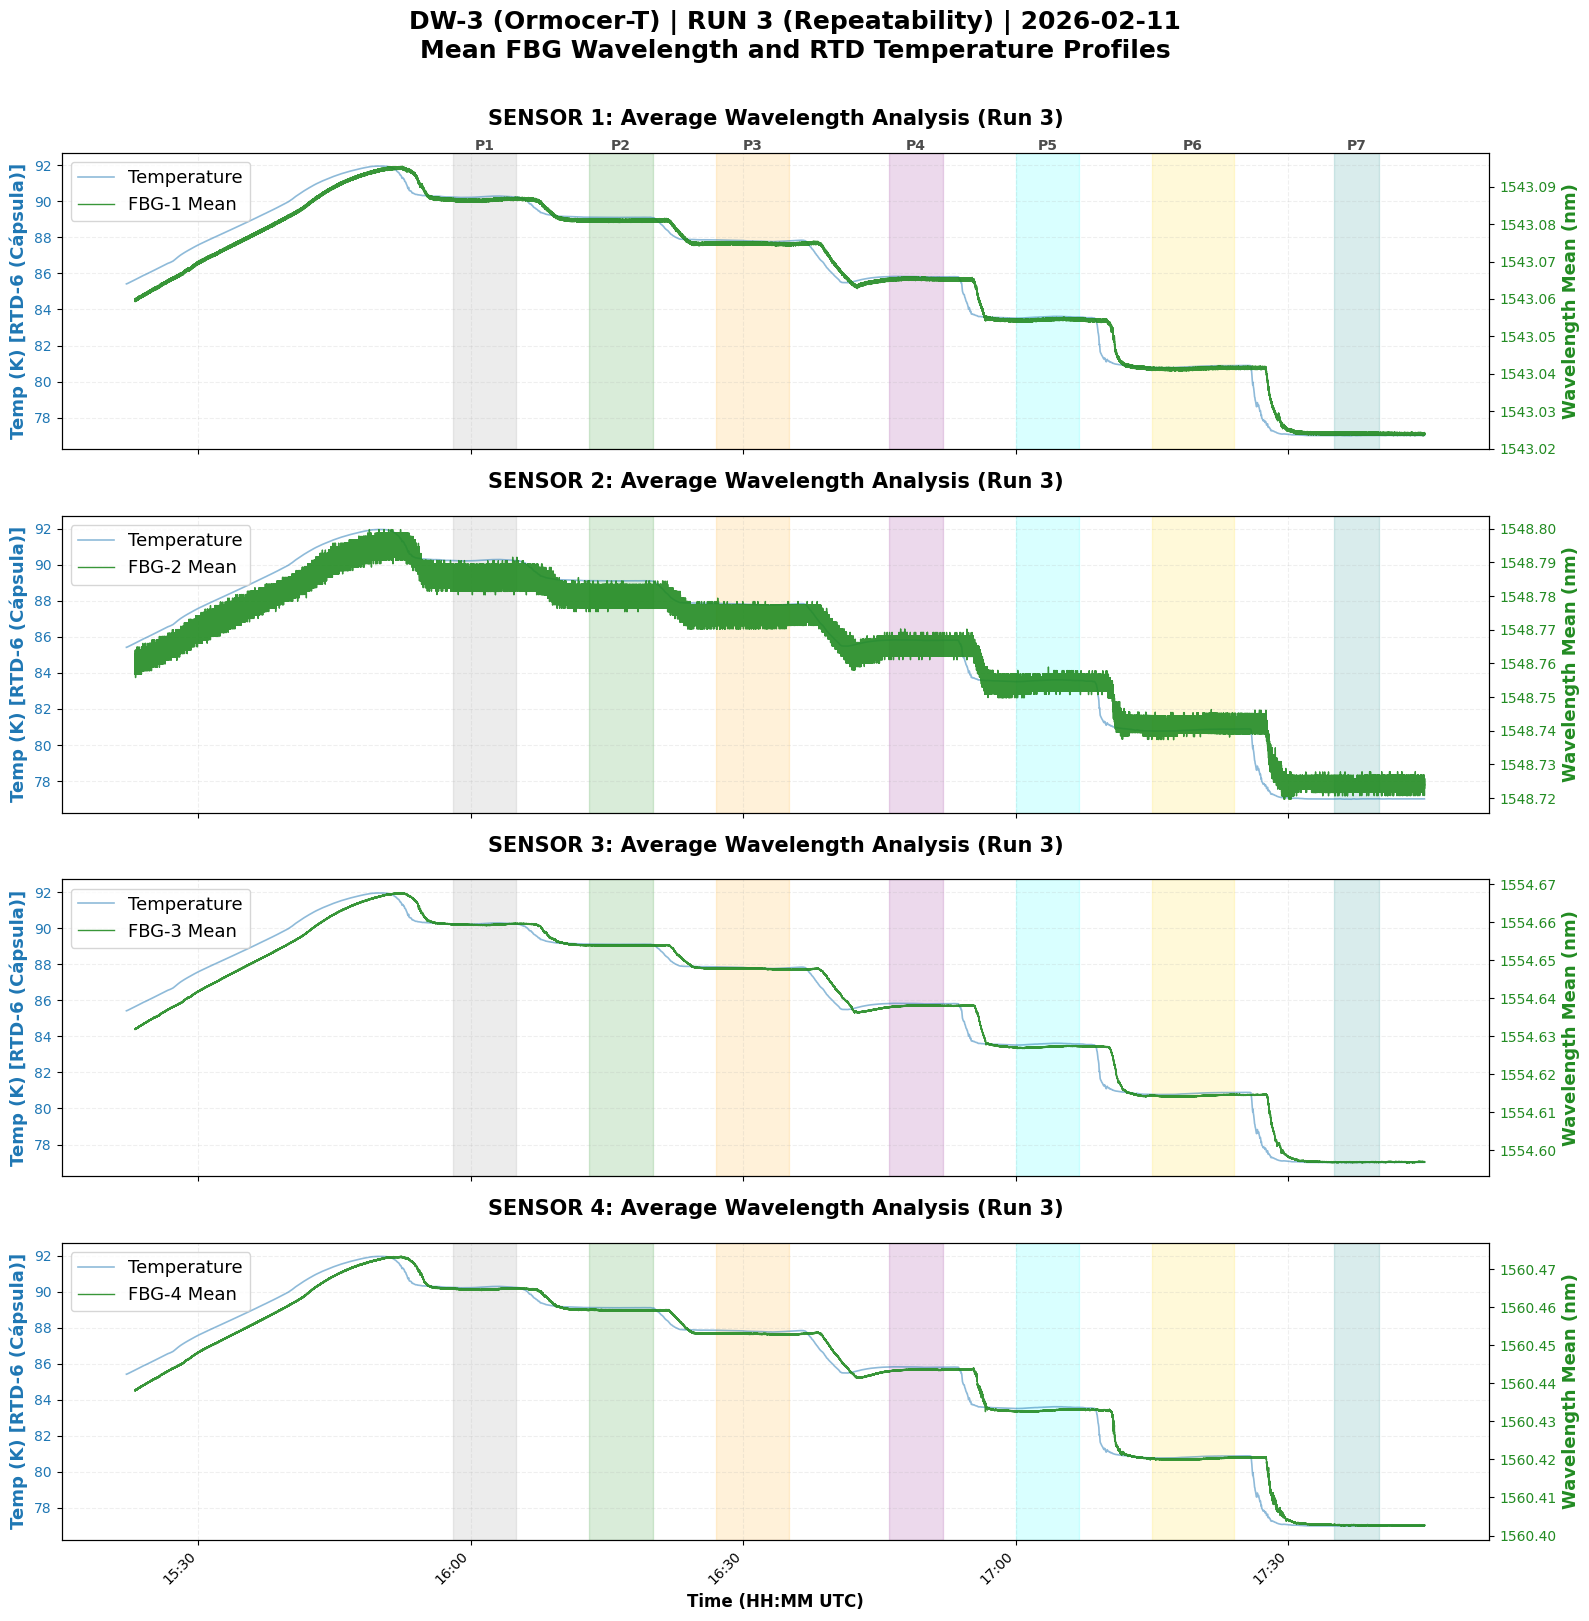

✅ Plot generated for Mean Wavelength (Run 3) with English labels and shaded plateaus.


In [15]:
# ============================================================================
# PLOT 1: Wavelength (MEAN) vs Temperature with Shaded Plateaus
# Fiber: DW-3 (Ormocer-T) | RUN 3 (Repeatability) | Date: 2026-02-11
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration
color_temp = 'tab:blue'
color_wav_mean = 'forestgreen'  # Color for the Average Wavelength
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan', 'gold', 'teal']

# Run 3 processed sensors
sensors_to_plot = [1, 2, 3, 4] 
fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(16, 4 * len(sensors_to_plot)), sharex=True)

# Ensure axes is iterable even if only one sensor is plotted
if len(sensors_to_plot) == 1: axes = [axes]

for idx, sensor_num in enumerate(sensors_to_plot):
    label_mean = f"FBG-{sensor_num}-Mean"
    
    # Check if the mean data exists for this sensor
    if label_mean not in fbg_mean_data:
        print(f"⚠️ Mean data missing for Sensor {sensor_num}, skipping...")
        continue
        
    data_mean = fbg_mean_data[label_mean]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD-6 Reference)
    ax1.set_ylabel(f'Temp (K) [{rtd_ref_name}]', fontsize=13, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.2, alpha=0.5, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # 2. Add Shaded Plateaus
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.15)
            # Add plateau labels at the top of the first subplot
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontweight='bold', alpha=0.7)

    # 3. Right Axis: Wavelength (Mean of P & S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength Mean (nm)', fontsize=13, color=color_wav_mean, fontweight='bold')
    ax2.plot(data_mean["timestamps"], data_mean["wavelength"], 
             color=color_wav_mean, linewidth=1.0, alpha=0.9, label=f'FBG-{sensor_num} Mean')
    
    ax2.tick_params(axis='y', labelcolor=color_wav_mean)
    ax2.ticklabel_format(useOffset=False, axis='y')
    
    # Titles and Legends
    ax1.set_title(f'SENSOR {sensor_num}: Average Wavelength Analysis (Run 3)', fontsize=15, fontweight='bold', pad=20)
    
    # Merge legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=13, framealpha=0.8)

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=12, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

# Overall Figure Title
plt.suptitle(f'DW-3 (Ormocer-T) | RUN 3 (Repeatability) | 2026-02-11\nMean FBG Wavelength and RTD Temperature Profiles', 
             fontsize=18, y=1.01, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Plot generated for Mean Wavelength (Run 3) with English labels and shaded plateaus.")

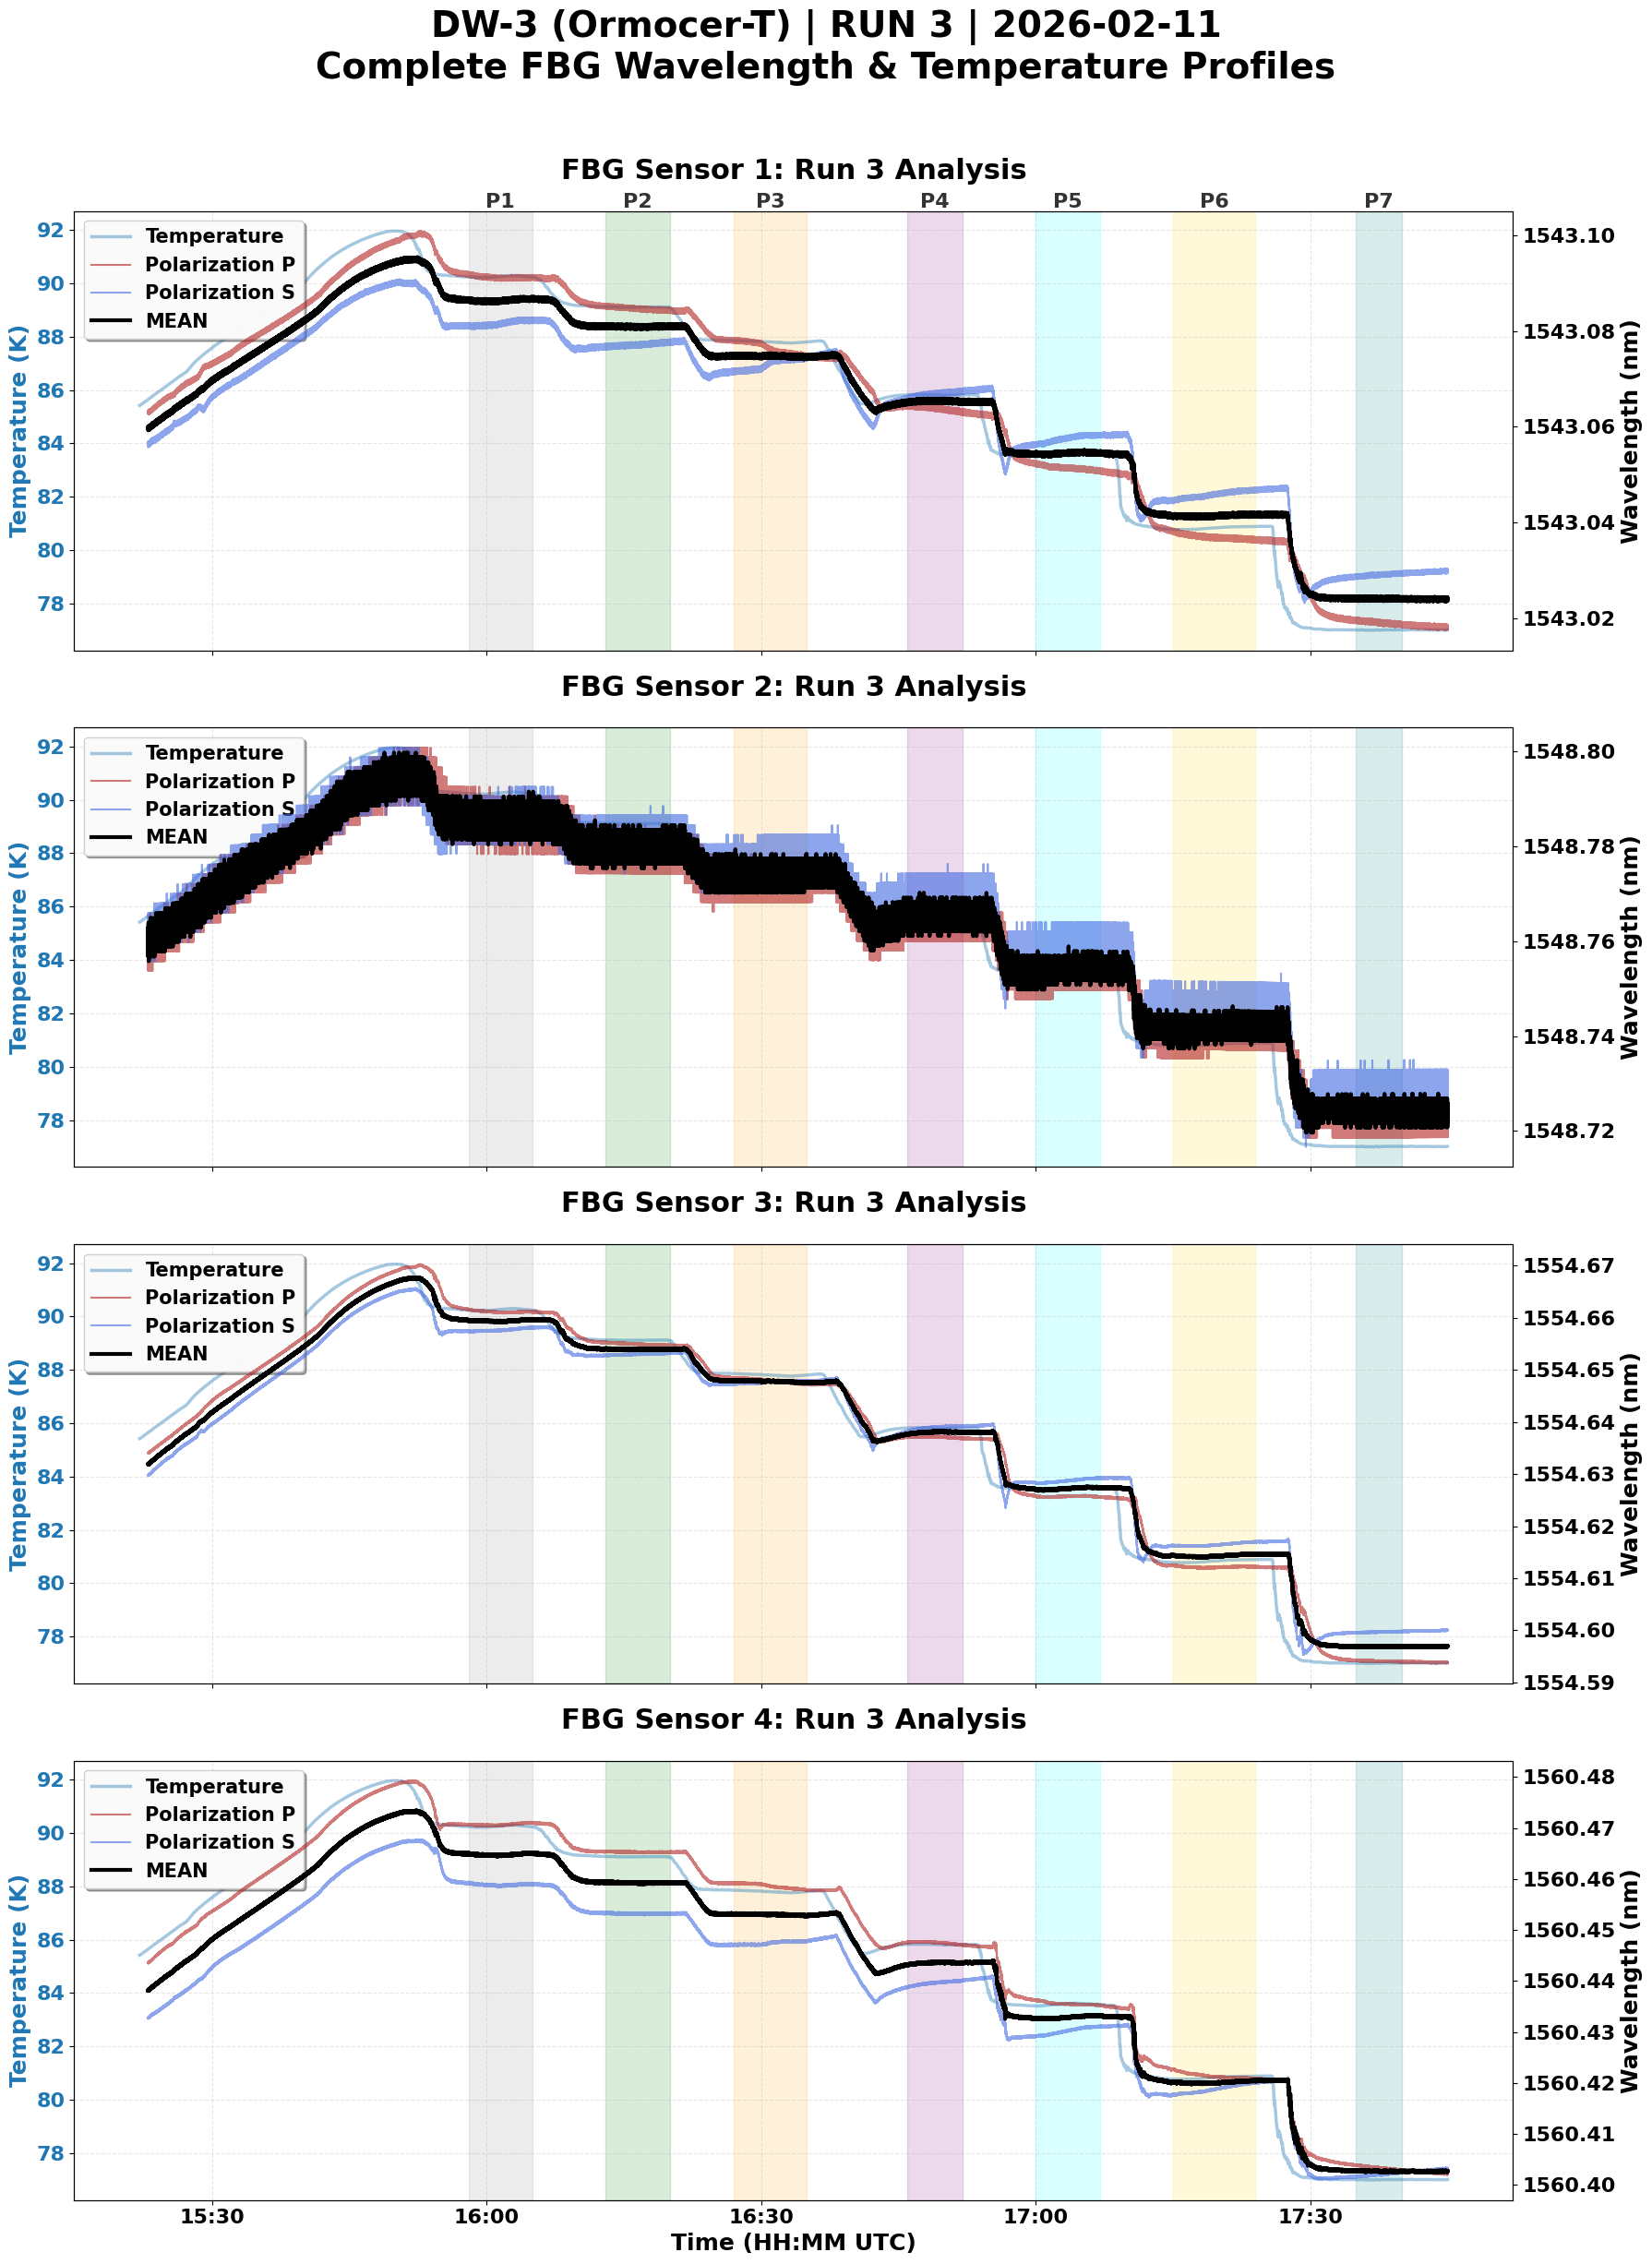

✅ High-visibility plot for Run 3 (Feb 11) generated successfully.


In [27]:
# ============================================================================
# PLOT 1: Wavelength (P, S & MEAN) vs Temperature with Shaded Plateaus
# Fiber: DW-3 (Ormocer-T) | RUN 3 | Date: 2026-02-11
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuration (High Visibility for Slides)
color_temp = 'tab:blue'
color_pol_p = 'firebrick'   # Polarization P
color_pol_s = 'royalblue'   # Polarization S
color_wav_mean = 'black'    # Mean in Black for high contrast
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan', 'gold', 'teal']

# Using all 4 sensors available in Run 3
sensors_to_plot = [1, 2, 3, 4]
fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(18, 6 * len(sensors_to_plot)), sharex=True)

# Ensure axes is iterable
if len(sensors_to_plot) == 1: axes = [axes]

for idx, sensor_num in enumerate(sensors_to_plot):
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    # Check if data exists in your dictionaries
    if label_p not in fbg_filtered_data or label_mean not in fbg_mean_data:
        print(f"⚠️ Data missing for Sensor {sensor_num} in Run 3, skipping...")
        continue
        
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    data_mean = fbg_mean_data[label_mean]
    ax1 = axes[idx]
    
    # 1. Left Axis: Temperature (RTD Reference)
    ax1.set_ylabel('Temperature (K)', fontsize=18, color=color_temp, fontweight='bold')
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=2.5, alpha=0.4, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color_temp, labelsize=16)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 2. Add Shaded Plateaus (Color bands)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for p_idx, plateau in enumerate(plateau_data):
            p_color = plateau_colors[p_idx % len(plateau_colors)]
            ax1.axvspan(plateau["t0"], plateau["tfin"], color=p_color, alpha=0.15)
            if idx == 0:
                mid_time = plateau["t0"] + (plateau["tfin"] - plateau["t0"]) / 2
                ax1.text(mid_time, ax1.get_ylim()[1], f'P{p_idx+1}', 
                         ha='center', va='bottom', fontweight='bold', fontsize=16, alpha=0.8)

    # 3. Right Axis: Wavelengths (P, S and Mean Superimposed)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=18, color='black', fontweight='bold')
    
    # Plot P and S (Background lines)
    ax2.plot(data_p["timestamps"], data_p["wavelength"], color=color_pol_p, 
             linewidth=1.5, alpha=0.6, label='Polarization P')
    ax2.plot(data_s["timestamps"], data_s["wavelength"], color=color_pol_s, 
             linewidth=1.5, alpha=0.6, label='Polarization S')
    
    # Plot MEAN (Main focus: Thicker Black line)
    ax2.plot(data_mean["timestamps"], data_mean["wavelength"], 
             color=color_wav_mean, linewidth=3.0, alpha=1.0, label='MEAN')
    
    ax2.tick_params(axis='y', labelcolor='black', labelsize=16)
    ax2.ticklabel_format(useOffset=False, axis='y')
    
    # Titles and Legends
    ax1.set_title(f'FBG Sensor {sensor_num}: Run 3 Analysis', 
                  fontsize=22, fontweight='bold', pad=25)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
                     frameon=True, shadow=True, framealpha=0.95, 
                     prop={'size': 15, 'weight': 'bold'})

# Format X-Axis (Time)
axes[-1].set_xlabel('Time (HH:MM UTC)', fontsize=18, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(axes[-1].get_xticklabels(), fontsize=16, fontweight='bold')

# Overall Figure Title
plt.suptitle(f'DW-3 (Ormocer-T) | RUN 3 | 2026-02-11\nComplete FBG Wavelength & Temperature Profiles', 
             fontsize=28, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ High-visibility plot for Run 3 (Feb 11) generated successfully.")

### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [16]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "press_mean": plateau["press_mean"],
                "press_std": plateau["press_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 7 plateaus procesados
FBG-2: 7 plateaus procesados
FBG-3: 7 plateaus procesados
FBG-4: 7 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

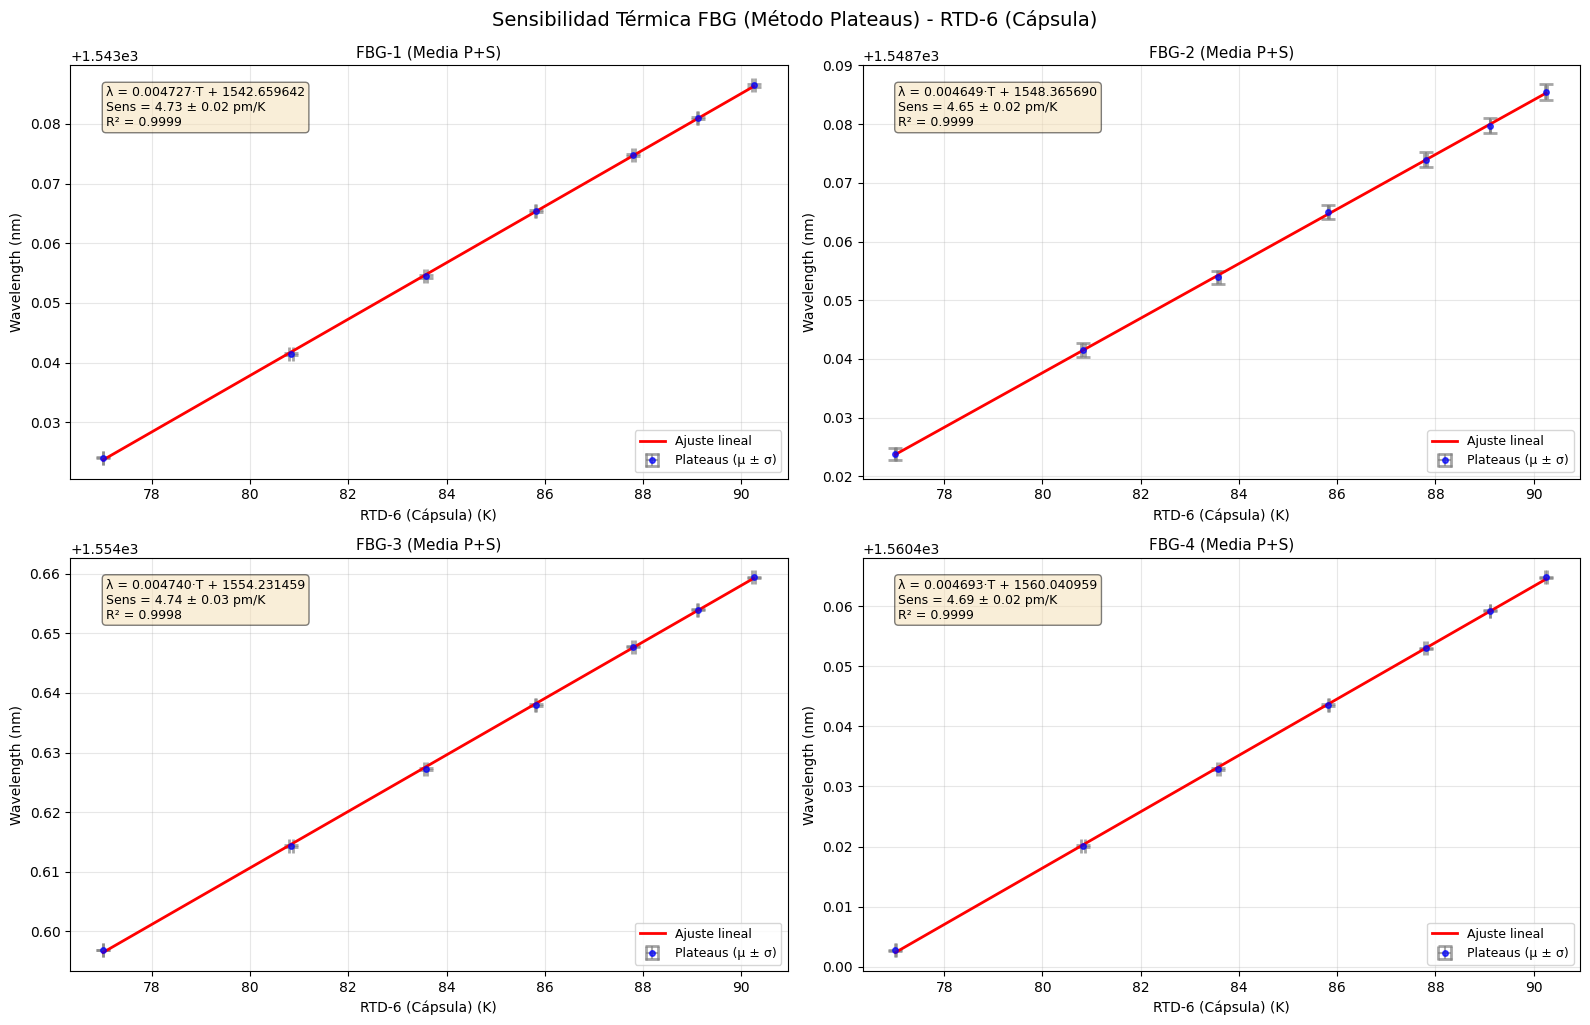


                               TABLA DE SENSIBILIDADES TÉRMICAS                                
Sensor          Sensibilidad (pm/K)       R²           N Plateaus   p-value
FBG-1               4.73 ± 0.02           0.999875     7            5.92e-11
FBG-2               4.65 ± 0.02           0.999884     7            4.88e-11
FBG-3               4.74 ± 0.03           0.999828     7            1.32e-10
FBG-4               4.69 ± 0.02           0.999878     7            5.55e-11


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ajustar layout para 3 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades
plateau_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal
    temp_means = np.array([p["temp_mean"] for p in plateau_stats])
    temp_stds = np.array([p["temp_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # 1. AJUSTE LINEAL
    slope, intercept, r_value, p_value, std_err = stats.linregress(temp_means, wav_means)
    
    # 2. CÁLCULOS DE SENSIBILIDAD E INCERTIDUMBRE (Se definen AQUÍ para evitar errores)
    sensitivity_pm_K = slope * 1000
    sensitivity_err_pm_K = std_err * 1000  # Incertidumbre de la pendiente
    
    # 3. GUARDAR RESULTADOS EN DICCIONARIO
    plateau_sensitivities[fbg_label] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2,
        "p_value": p_value,
        "std_err": std_err,
        "sensitivity_pm_K": sensitivity_pm_K,
        "sensitivity_err_pm_K": sensitivity_err_pm_K,
        "n_plateaus": len(plateau_stats)
    }
    
    # 4. CONFIGURACIÓN DEL PLOT
    ax = axes[idx]
    
    # Puntos con barras de error (μ ± σ)
    ax.errorbar(temp_means, wav_means, 
                xerr=temp_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='blue', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste lineal
    temp_range = np.array([temp_means.min(), temp_means.max()])
    wav_fit = slope * temp_range + intercept
    ax.plot(temp_range, wav_fit, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Cuadro de texto con la ecuación y la sensibilidad ± error
    equation_text = f'λ = {slope:.6f}·T + {intercept:.6f}\n'
    equation_text += f'Sens = {sensitivity_pm_K:.2f} ± {sensitivity_err_pm_K:.2f} pm/K\n'
    equation_text += f'R² = {r_value**2:.4f}'
    
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Títulos y etiquetas de ejes
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel(f'{rtd_ref_name} (K)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

# Ajustes finales de la figura
plt.tight_layout()
plt.suptitle(f'Sensibilidad Térmica FBG (Método Plateaus) - {rtd_ref_name}', 
             fontsize=14, y=1.02)
plt.show()

# 5. RESUMEN FINAL EN TABLA
print("\n" + "="*95)
print(f"{'TABLA DE SENSIBILIDADES TÉRMICAS':^95}")
print("="*95)
print(f"{'Sensor':<15} {'Sensibilidad (pm/K)':<25} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*95)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_sensitivities[fbg_label]
        
        # Formatear el string de sensibilidad con su incertidumbre
        sens_str = f"{sens_data['sensitivity_pm_K']:>8.2f} ± {sens_data['sensitivity_err_pm_K']:<6.2f}"
        
        print(f"FBG-{sensor_num:<11} {sens_str:<25} "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*95)

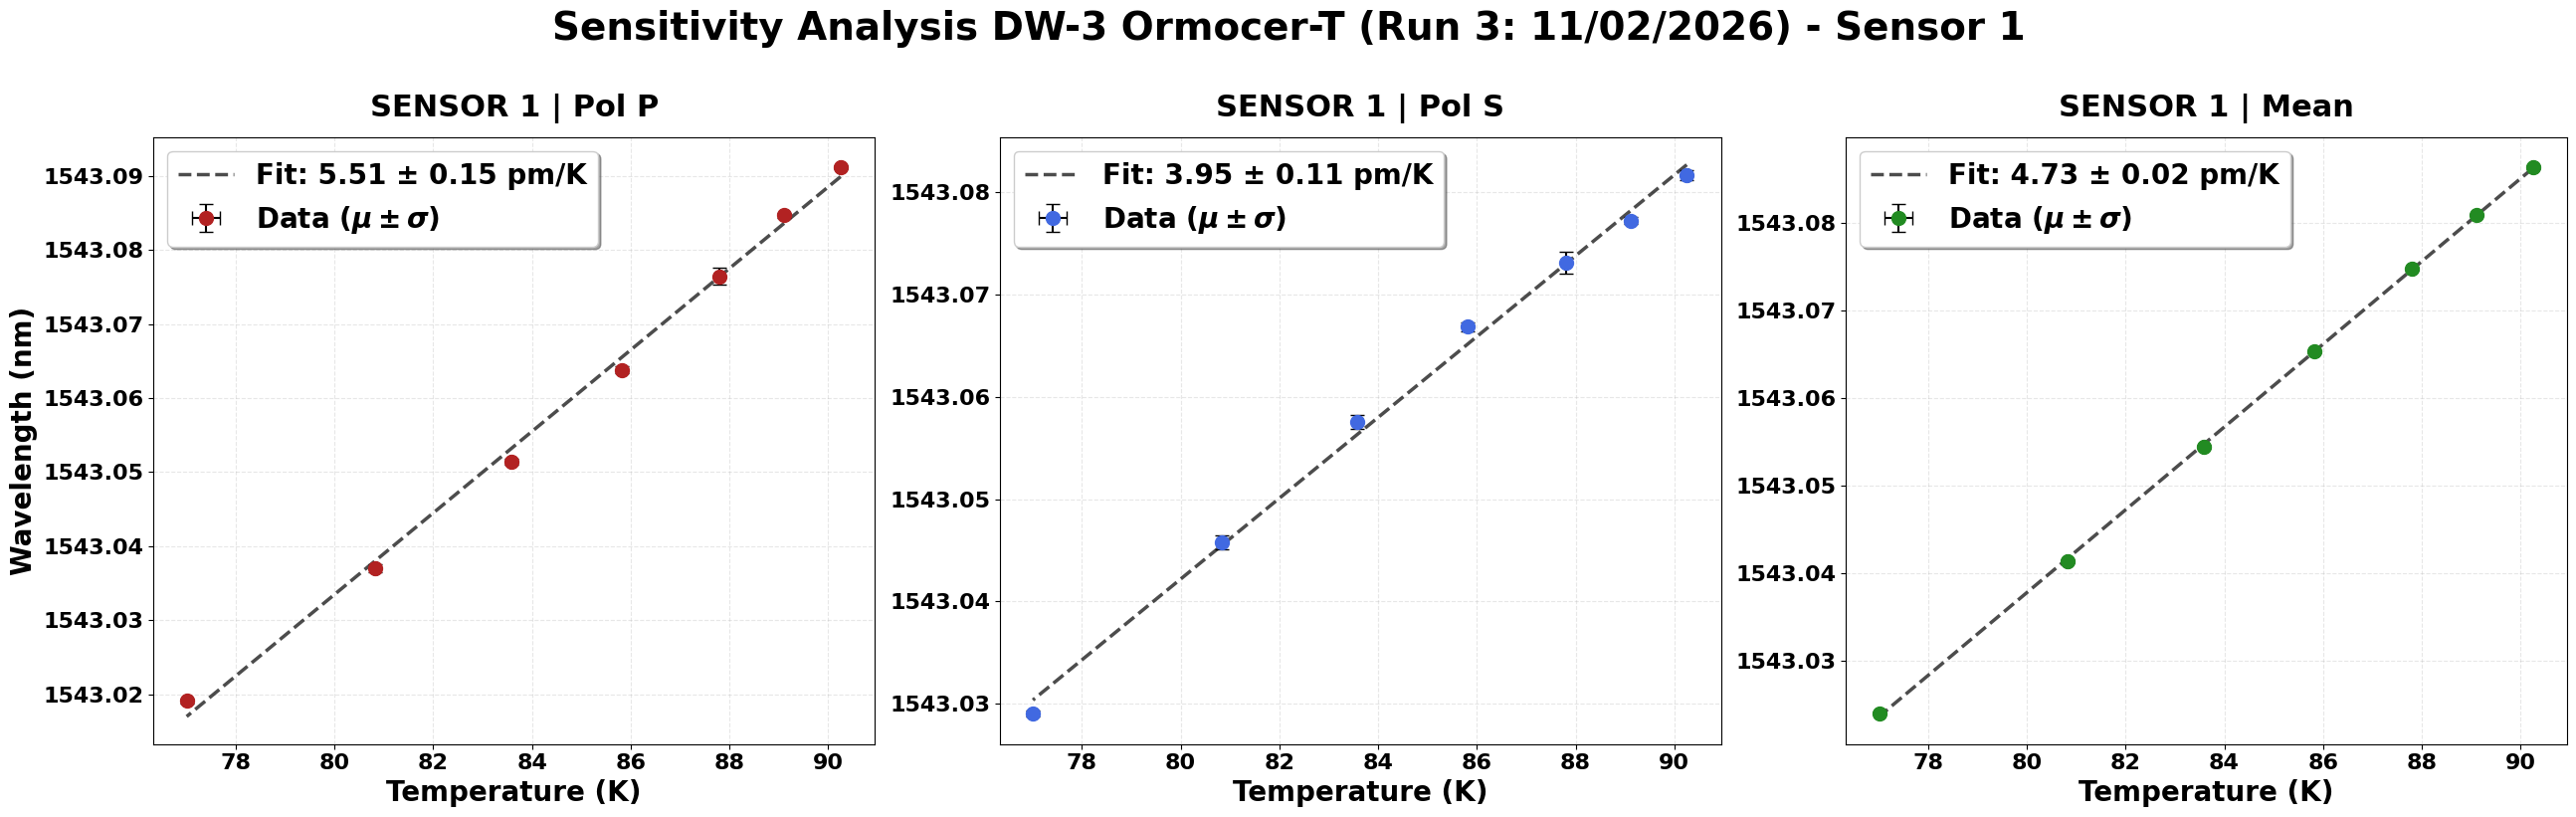

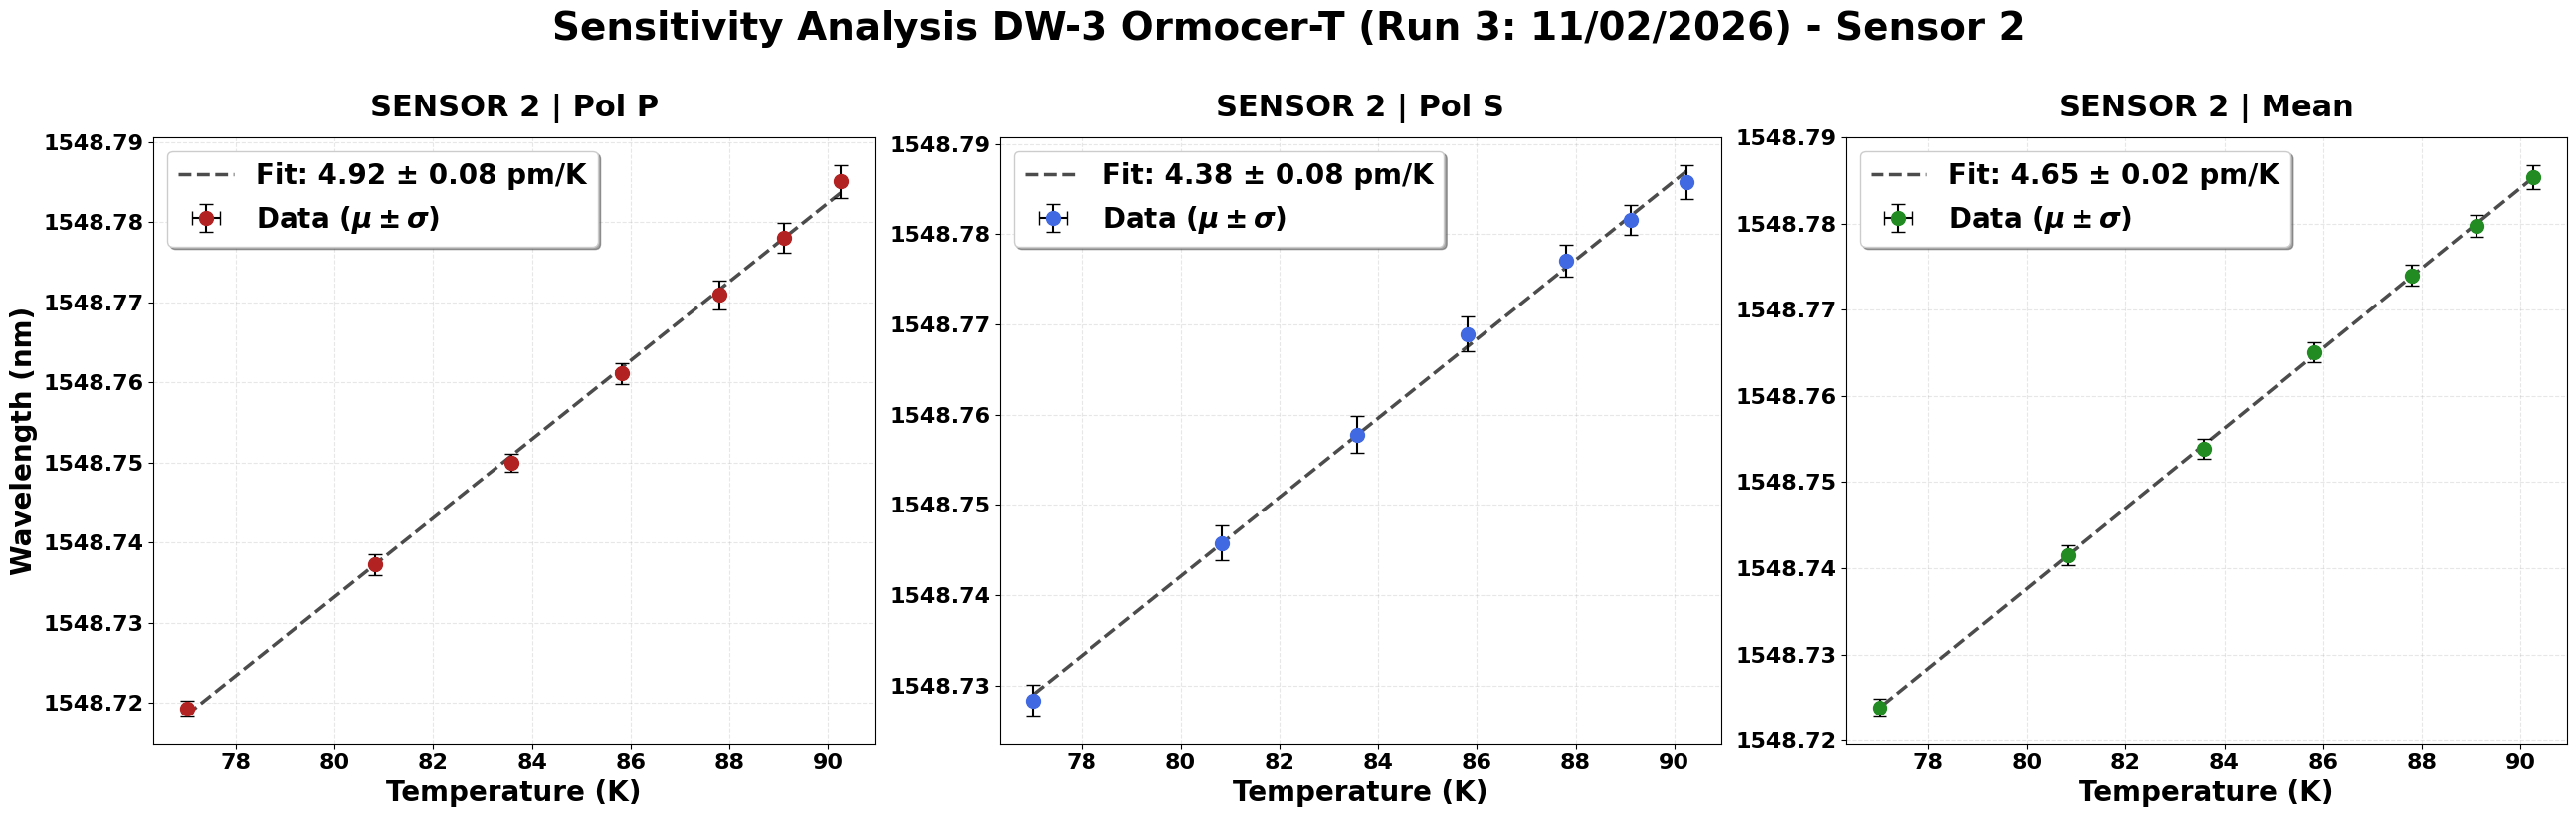

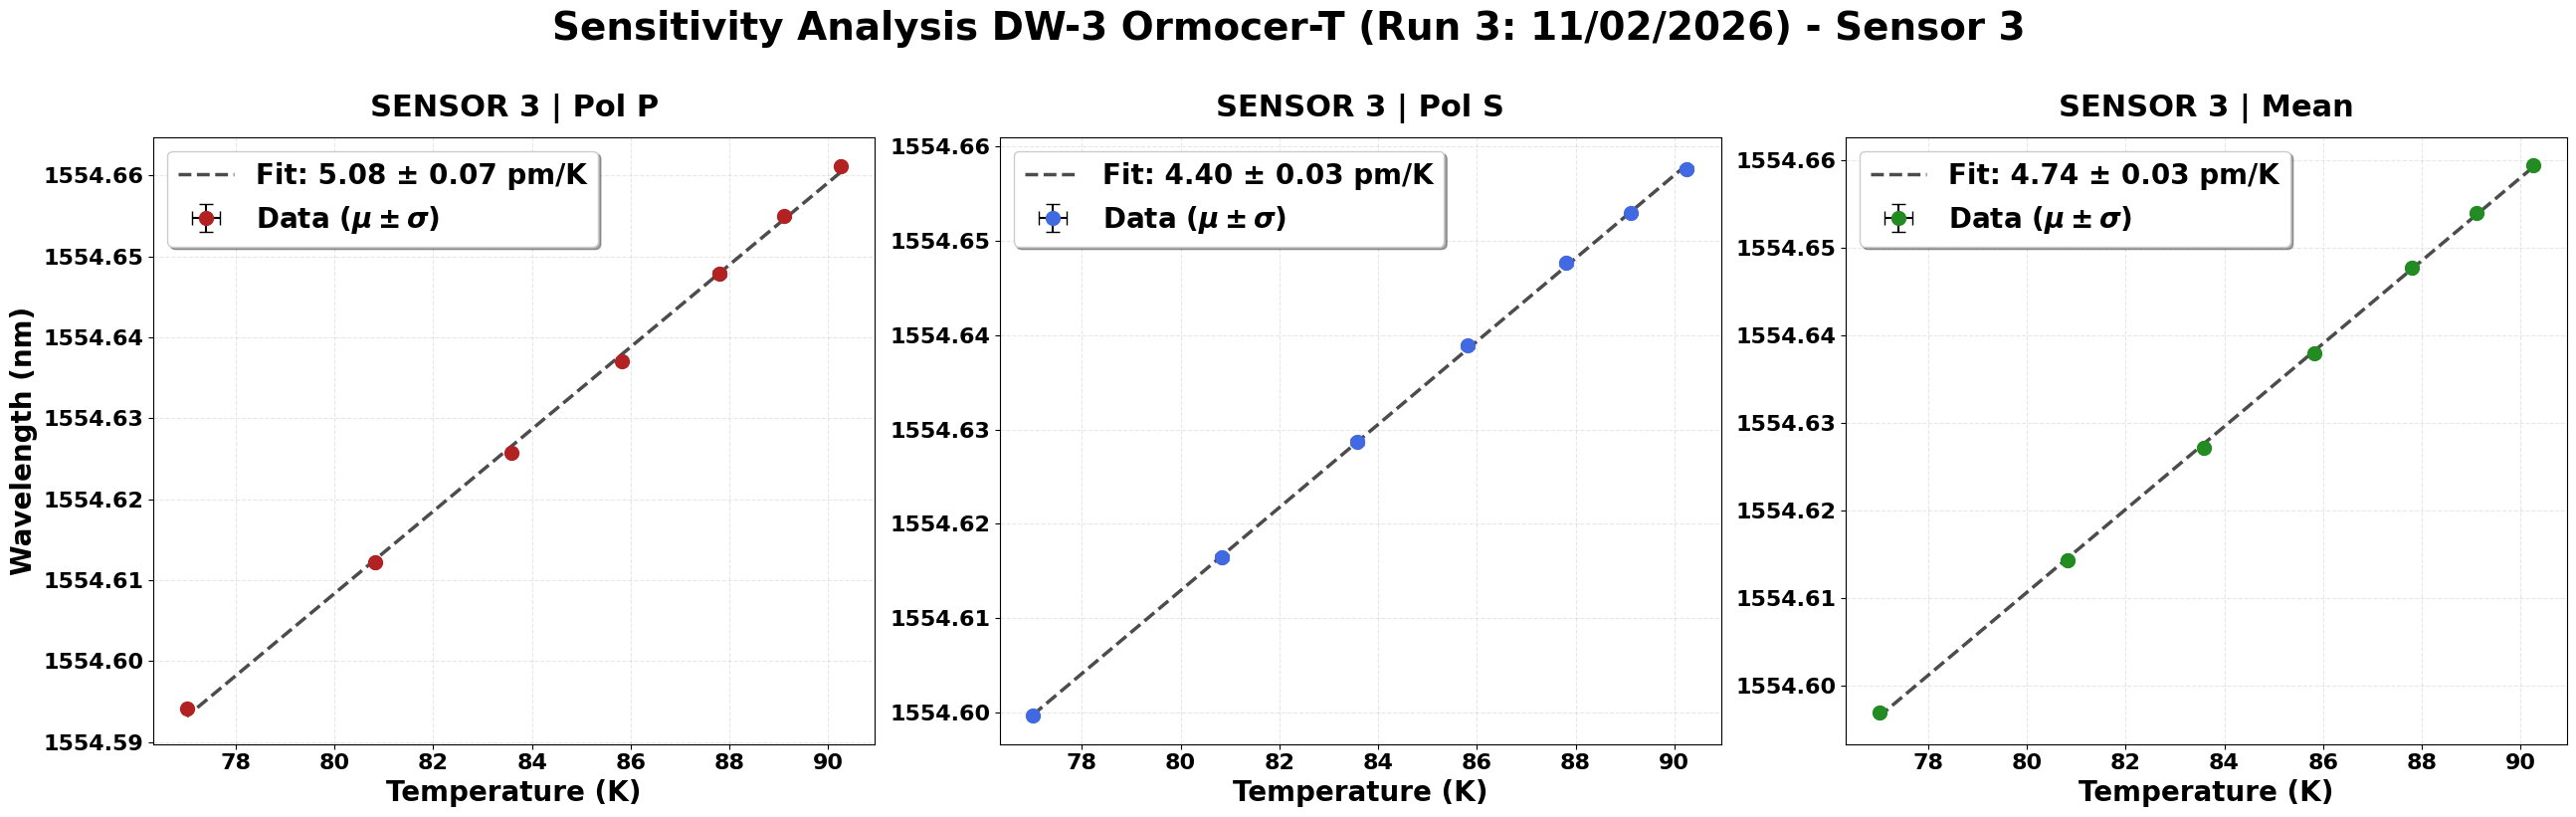

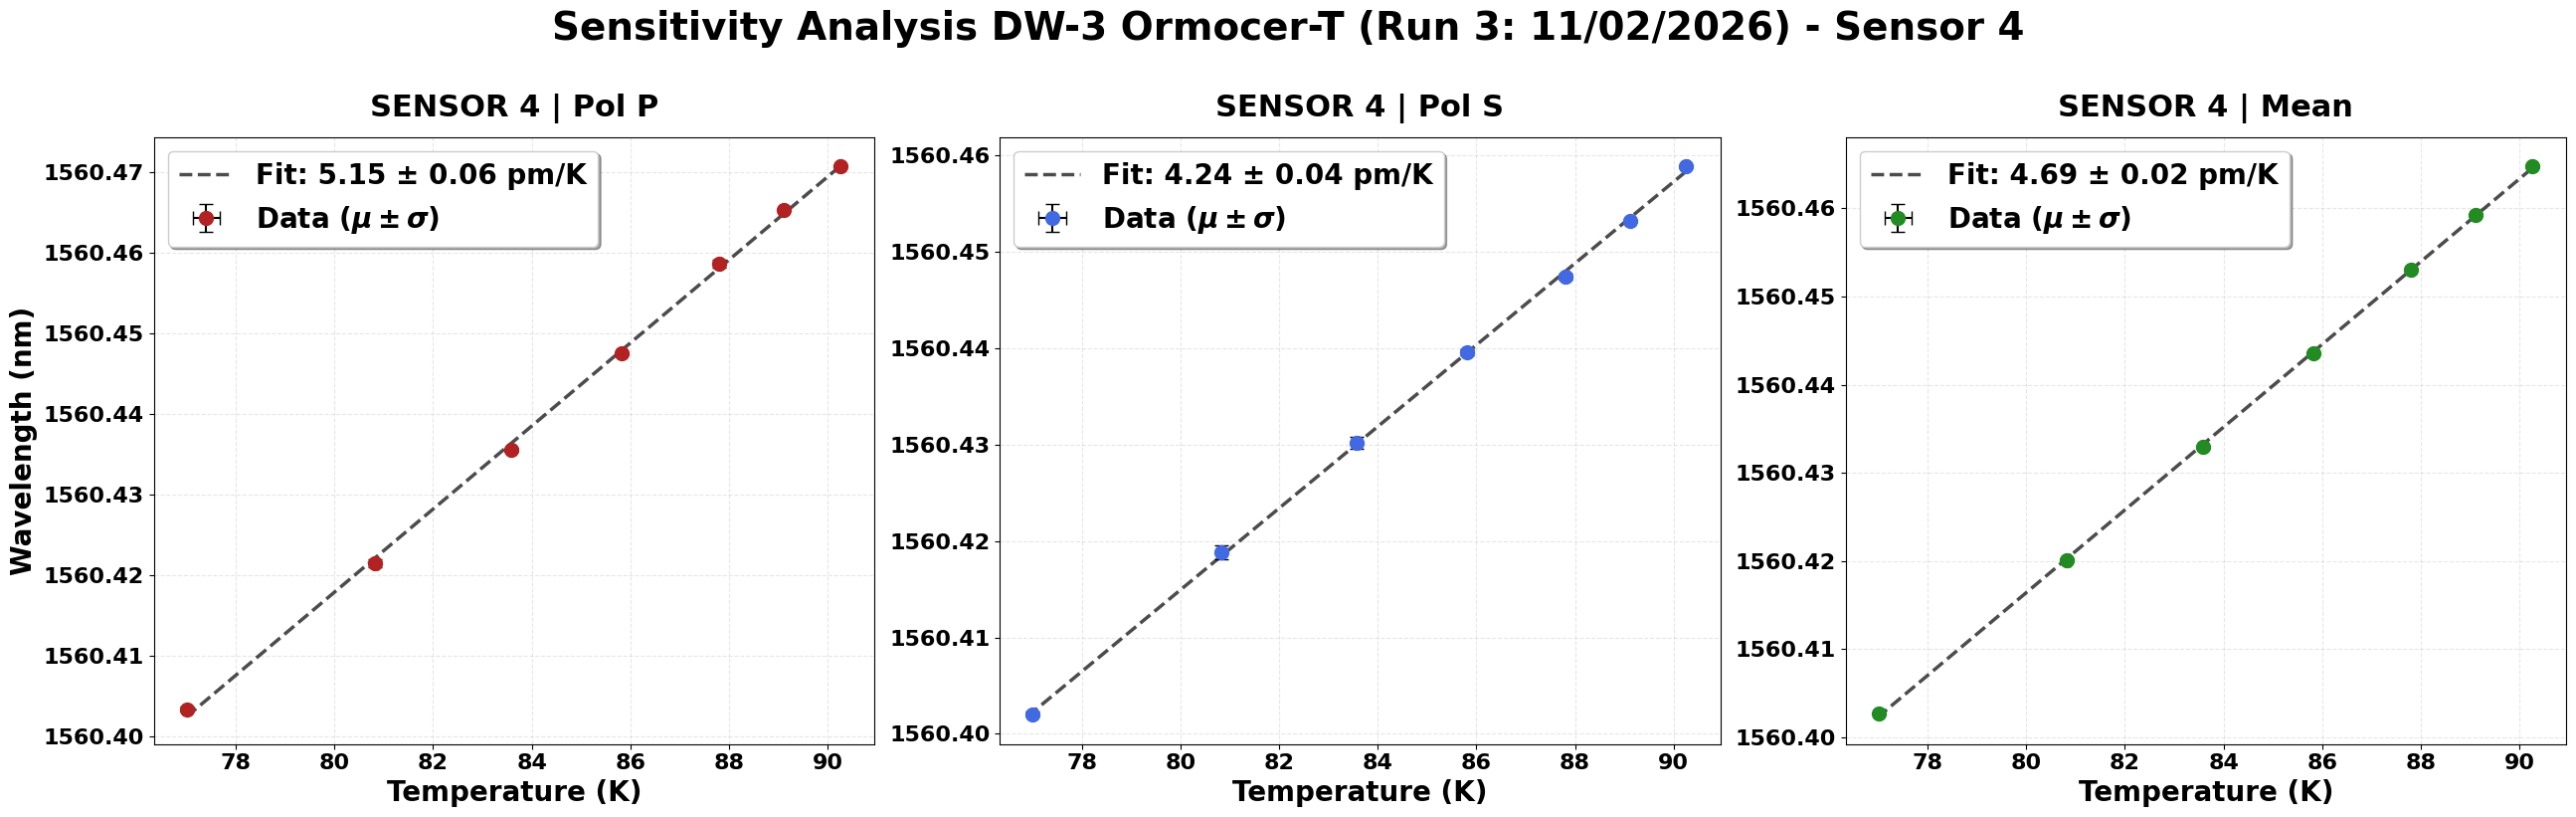


                         SENSITIVITY SUMMARY TABLE: RUN 3 (11/02/2026)                         
Sensor       | Type         | Slope (pm/K)       | Error (pm/K)    | R²      
-----------------------------------------------------------------------------------------------
Sensor 1     | Pol P        |        5.508       |        0.145    | 0.9965
Sensor 1     | Pol S        |        3.947       |        0.109    | 0.9962
Sensor 1     | Mean         |        4.727       |        0.024    | 0.9999
Sensor 2     | Pol P        |        4.919       |        0.080    | 0.9987
Sensor 2     | Pol S        |        4.381       |        0.081    | 0.9983
Sensor 2     | Mean         |        4.649       |        0.022    | 0.9999
Sensor 3     | Pol P        |        5.076       |        0.067    | 0.9991
Sensor 3     | Pol S        |        4.403       |        0.026    | 0.9998
Sensor 3     | Mean         |        4.740       |        0.028    | 0.9998
Sensor 4     | Pol P        |        5.150   

In [18]:
# ============================================================================
# PLOT 2 (RUN 3 - 11/02): Sensitivity Fits & Summary Table
# Fiber: DW-3 | 4 Sensors | Includes Slope Error | HIGH VISIBILITY MODE
# ============================================================================

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Configuración de fuentes globales para asegurar negrita en todo
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

summary_results = []

for sensor_num in [1, 2, 3, 4]:
    # Aumentamos el tamaño de la figura para acomodar fuentes más grandes
    fig, axes = plt.subplots(1, 3, figsize=(26, 8), sharey=False)
    
    configs = [
        {"key": f"FBG-{sensor_num}-P", "title": "Pol P", "color": "firebrick", "src": fbg_filtered_data},
        {"key": f"FBG-{sensor_num}-S", "title": "Pol S", "color": "royalblue", "src": fbg_filtered_data},
        {"key": f"FBG-{sensor_num}-Mean", "title": "Mean", "color": "forestgreen", "src": fbg_mean_data}
    ]

    for idx, cfg in enumerate(configs):
        ax = axes[idx]
        label, source = cfg["key"], cfg["src"]
        
        if label not in source: continue
        
        t_m, t_s, w_m, w_s = [], [], [], []
        for p in plateau_data:
            mask = (source[label]["timestamps"] >= p["t0"]) & (source[label]["timestamps"] <= p["tfin"])
            wav_slice = source[label]["wavelength"][mask]
            if len(wav_slice) > 0:
                t_m.append(p["temp_mean"]); t_s.append(p["temp_std"])
                w_m.append(np.mean(wav_slice)); w_s.append(np.std(wav_slice))

        x, y, xe, ye = np.array(t_m), np.array(w_m), np.array(t_s), np.array(w_s)
        if len(x) > 1:
            slope, intercept, r_val, _, std_err = stats.linregress(x, y)
            s_pm, e_pm = slope * 1e3, std_err * 1e3
            summary_results.append({"S": f"Sensor {sensor_num}", "T": cfg["title"], "Slope": s_pm, "Err": e_pm, "R2": r_val**2})

            # Plot de datos y ajuste
            ax.errorbar(x, y, xerr=xe, yerr=ye, fmt='o', color=cfg["color"], 
                        ecolor='black', capsize=5, markersize=10, label='Data ($\mu \pm \sigma$)')
            ax.plot(x, slope*x + intercept, 'k--', linewidth=2.5, alpha=0.7, 
                    label=f'Fit: {s_pm:.2f} ± {e_pm:.2f} pm/K')
            
            # Títulos y Ejes (FUENTES MUCHO MÁS GRANDES)
            ax.set_title(f"SENSOR {sensor_num} | {cfg['title']}", fontsize=22, fontweight='bold', pad=15)
            ax.set_xlabel("Temperature (K)", fontsize=20, fontweight='bold')
            if idx == 0: # Solo ponemos el label de Y en el primero para no saturar, o en todos si prefieres
                ax.set_ylabel("Wavelength (nm)", fontsize=20, fontweight='bold')
            
            # TICKS EN NEGRITA Y GRANDES
            ax.tick_params(axis='both', which='major', labelsize=16)
            for tick in ax.get_xticklabels(): tick.set_fontweight('bold')
            for tick in ax.get_yticklabels(): tick.set_fontweight('bold')

            # LEYENDA Y FORMATO
            ax.legend(fontsize=20, frameon=True, shadow=True)
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.ticklabel_format(useOffset=False, axis='y')

    # Título superior de la figura
    plt.suptitle(f"Sensitivity Analysis DW-3 Ormocer-T (Run 3: 11/02/2026) - Sensor {sensor_num}", 
                 fontsize=28, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

# Print Table (Consola)
print("\n" + "="*95)
print(f"{'SENSITIVITY SUMMARY TABLE: RUN 3 (11/02/2026)':^95}")
print("="*95)
print(f"{'Sensor':<12} | {'Type':<12} | {'Slope (pm/K)':<18} | {'Error (pm/K)':<15} | {'R²':<8}")
print("-" * 95)
for res in summary_results:
    print(f"{res['S']:<12} | {res['T']:<12} | {res['Slope']:>12.3f}       | {res['Err']:>12.3f}    | {res['R2']:.4f}")
print("="*95)

### 6.6 Visualizar Sensibilidad (Presión vs Wavelength con barras de error)

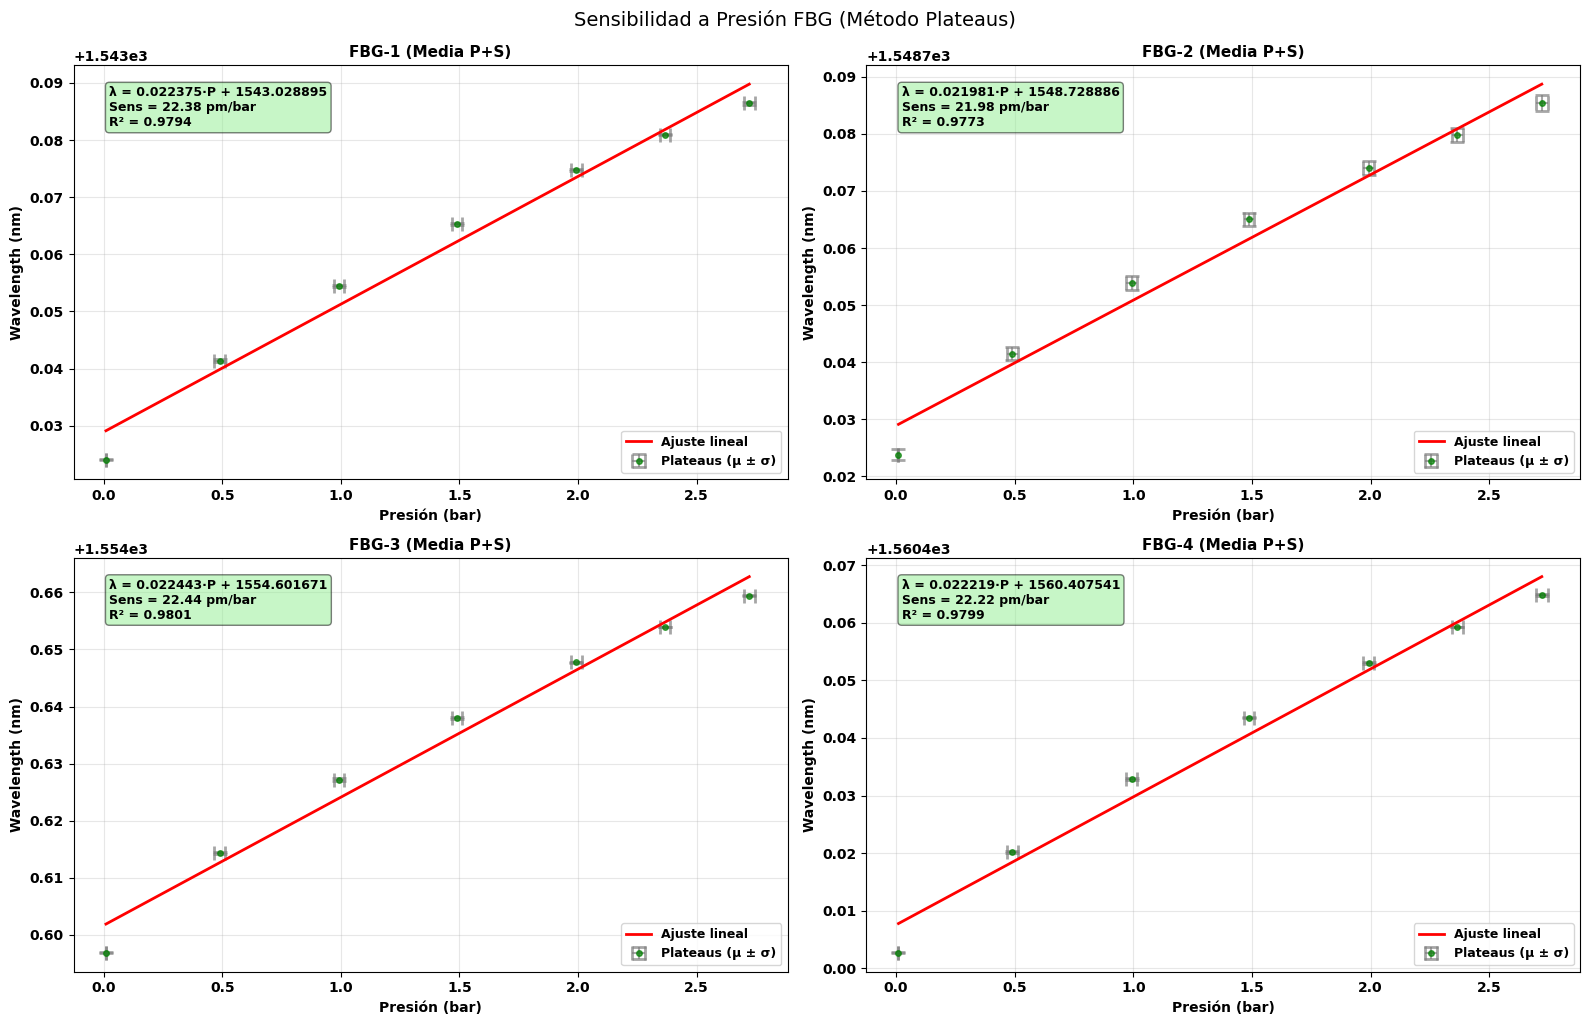


SENSIBILIDADES A PRESIÓN (Método Plateaus)
Sensor          Sensibilidad       R²           N Plateaus   p-value
FBG-1             22.38 pm/bar   0.979437     7            2.07e-05
FBG-2             21.98 pm/bar   0.977264     7            2.67e-05
FBG-3             22.44 pm/bar   0.980148     7            1.90e-05
FBG-4             22.22 pm/bar   0.979873     7            1.97e-05


In [19]:
# Ajustar layout para 3 sensores - Sensibilidad a presión
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades a presión
plateau_press_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal (presión vs wavelength)
    press_means = np.array([p["press_mean"] for p in plateau_stats])
    press_stds = np.array([p["press_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # Ajuste lineal
    slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(press_means, wav_means)
    
    # Guardar sensibilidad a presión
    plateau_press_sensitivities[fbg_label] = {
        "slope": slope_p,
        "intercept": intercept_p,
        "r_squared": r_value_p**2,
        "p_value": p_value_p,
        "std_err": std_err_p,
        "sensitivity_pm_bar": slope_p * 1000,  # nm/bar -> pm/bar
        "n_plateaus": len(plateau_stats)
    }
    
    # Plot
    ax = axes[idx]
    
    # Puntos con barras de error
    ax.errorbar(press_means, wav_means, 
                xerr=press_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='green', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste
    press_range = np.array([press_means.min(), press_means.max()])
    wav_fit_p = slope_p * press_range + intercept_p
    ax.plot(press_range, wav_fit_p, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Añadir ecuación de la recta en el plot
    sensitivity_pm_bar = slope_p * 1000
    equation_text = f'λ = {slope_p:.6f}·P + {intercept_p:.6f}\n'
    equation_text += f'Sens = {sensitivity_pm_bar:.2f} pm/bar\n'
    equation_text += f'R² = {r_value_p**2:.4f}'
    
    # Posicionar el texto en la esquina superior izquierda
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # Configuración del plot
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel('Presión (bar)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.suptitle(f'Sensibilidad a Presión FBG (Método Plateaus)', 
             fontsize=14, y=1.02)
plt.show()

# Resumen de sensibilidades a presión
print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Método Plateaus)")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*80)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_press_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_press_sensitivities[fbg_label]
        
        print(f"FBG-{sensor_num}        {sens_data['sensitivity_pm_bar']:>10.2f} pm/bar   "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*80)

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

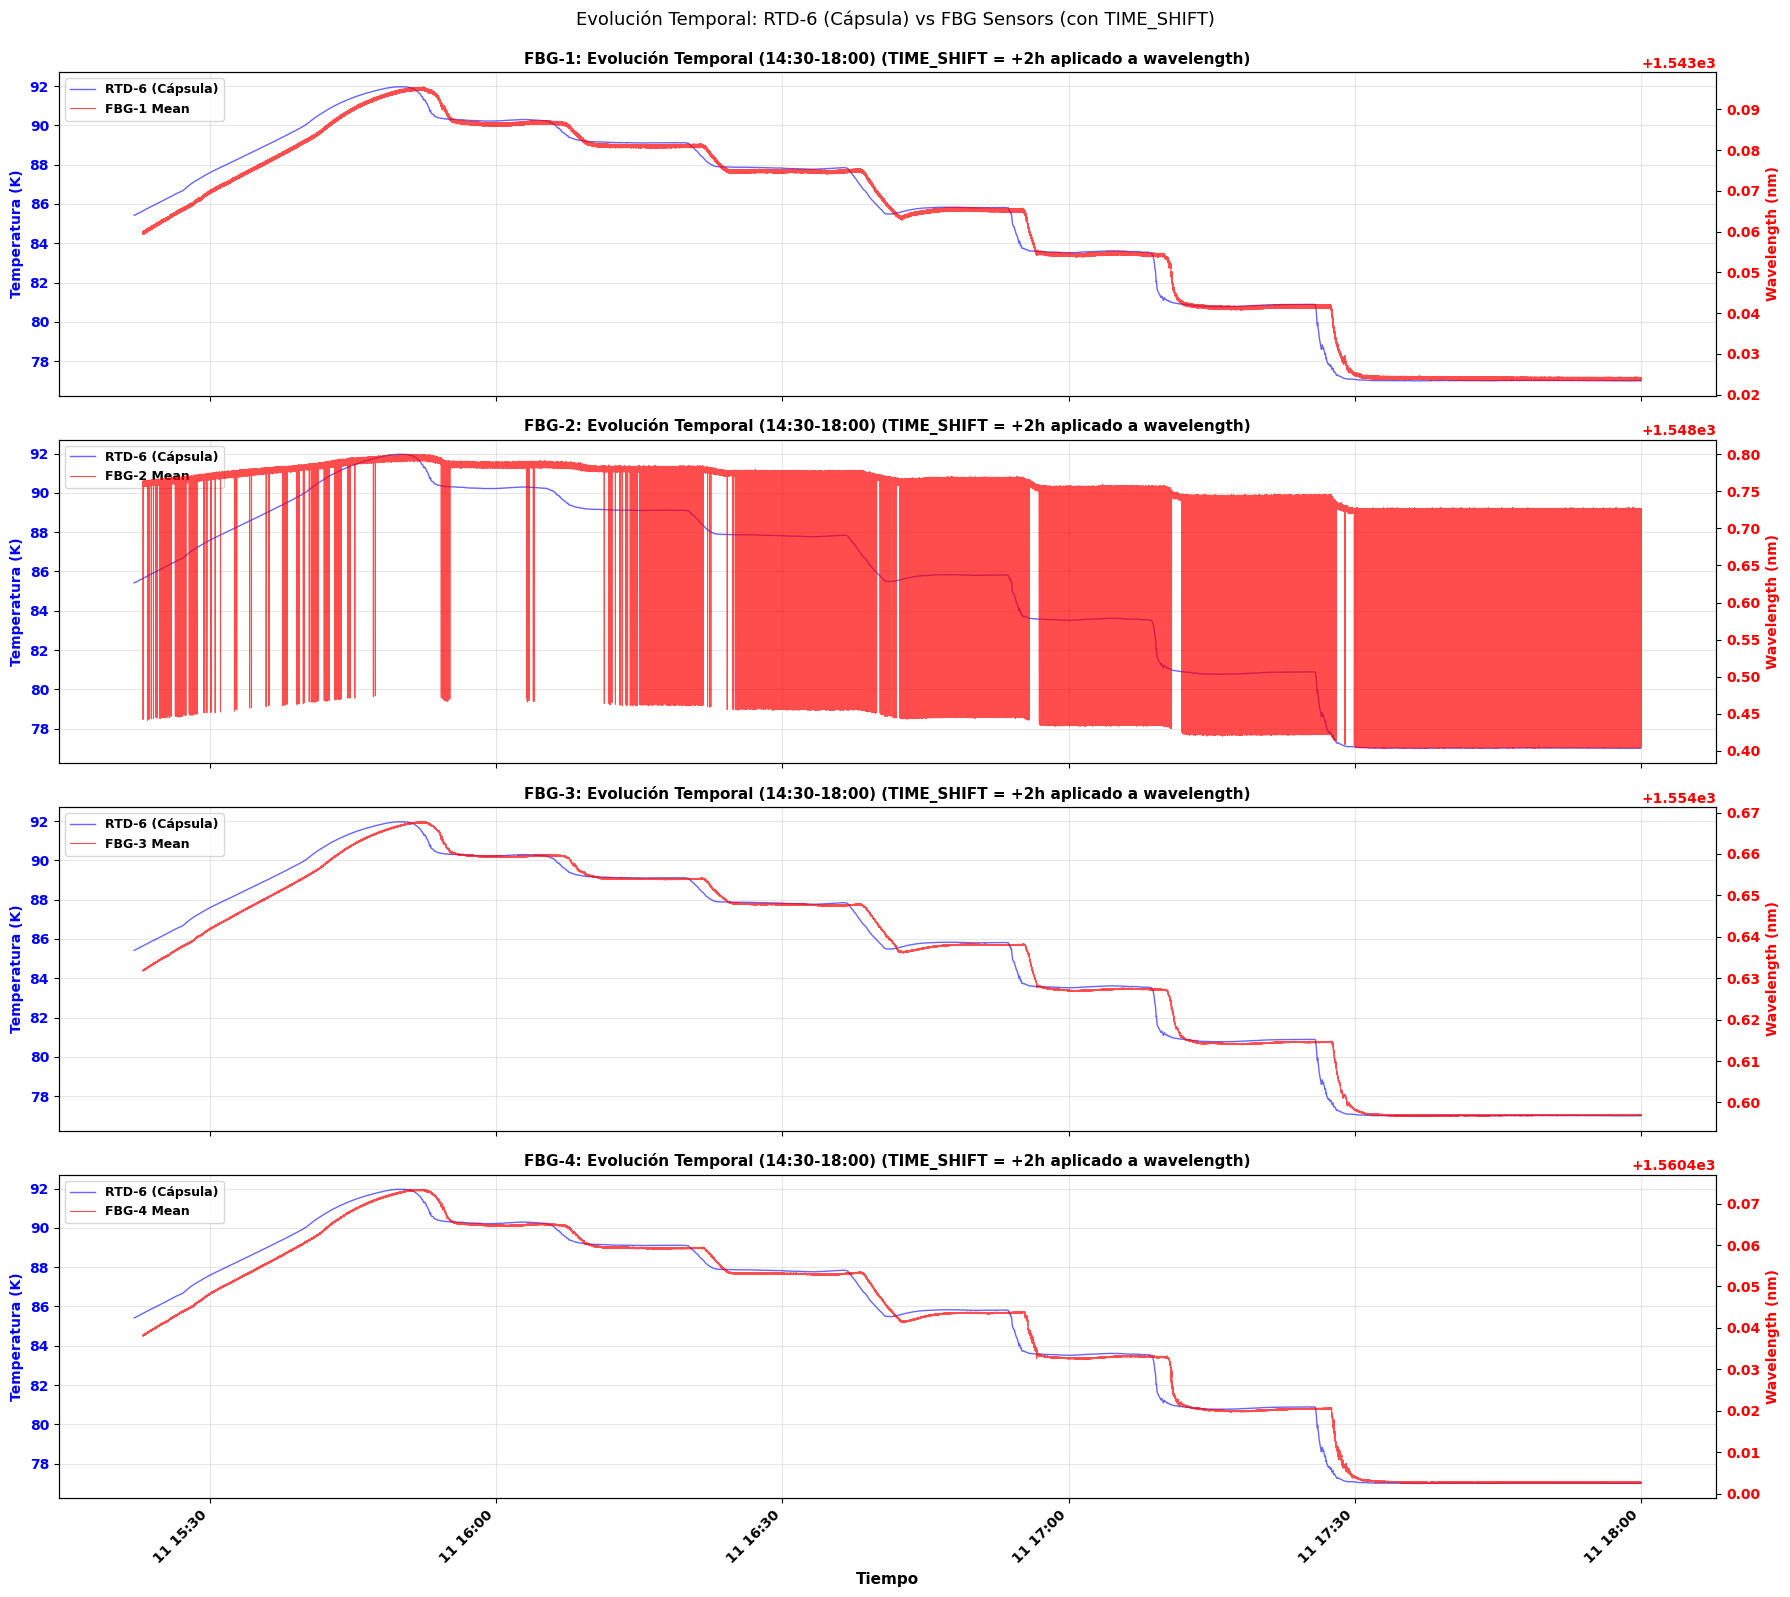


📊 Rango temporal mostrado: (14:30-18:00)
   Temperatura: 2026-02-11 15:22 - 17:59
   Wavelength (con +2h shift): 2026-02-11 15:23 - 17:59

💡 Este gráfico muestra el TIME_SHIFT de 2 horas aplicado a los datos de wavelength
   para alinearlos temporalmente con la temperatura.

⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'


In [20]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# Opción A: Mostrar TODO el rango temporal disponible
use_filtered_range_plot = True  # Cambiar a True para filtrar por un rango específico

if use_filtered_range_plot:
    # Opción B: Definir rango específico para visualización
    # Puedes usar el mismo rango de la Sección 3 o definir uno personalizado
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(14, 30))
    t_plot_fin = datetime.datetime.combine(fecha, datetime.time(18, 0))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_temp[0]
    t_plot_fin = times_temp[-1]
    range_label = "(Rango completo)"
# ============================================================================

# Ajustar número de subplots según sensores disponibles
n_sensors_temporal = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_temporal, 1, figsize=(18, 4*n_sensors_temporal), sharex=True)

# Asegurar que axes sea un array
if n_sensors_temporal == 1:
    axes = [axes]

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate([1, 2, 3, 4][:n_sensors_temporal]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    
    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S
    
    # Filtrar valores positivos y por rango temporal
    mask_p = (wav_p_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = (wav_s_full > 0) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    
    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)
    
    # Media (P+S)/2
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0
    
    ax = axes[idx]
    
    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)
    
    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)', 
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")

print(f"\n💡 Este gráfico muestra el TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f} horas aplicado a los datos de wavelength")
print(f"   para alinearlos temporalmente con la temperatura.")

if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

## 8️⃣ Resumen Final

In [21]:
print("\n" + "="*80)
print("RESUMEN COMPLETO DEL ANÁLISIS")
print("="*80)
print(f"Archivo: {filepath}")
print(f"Rango: {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"Temperatura referencia: {rtd_ref_name}")
print(f"Presión: ✅ Datos funcionales")
print(f"Plateaus manuales: {'SÍ' if use_manual_plateaus else 'NO'}")

print("\n" + "="*80)
print("SENSIBILIDADES TÉRMICAS (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_sensitivities[label]
    sensitivity_pm = sens['sensitivity_pm_K']
    all_sensitivities.append(sensitivity_pm)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm:>10.2f} pm/K     {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad Térmica):")
print(f"  Media: {np.mean(all_sensitivities):.2f} pm/K")
print(f"  Std: {np.std(all_sensitivities):.3f} pm/K")
print(f"  Rango: [{np.min(all_sensitivities):.2f}, {np.max(all_sensitivities):.2f}] pm/K")

print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_press_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_press_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_press_sensitivities[label]
    sensitivity_pm_bar = sens['sensitivity_pm_bar']
    all_press_sensitivities.append(sensitivity_pm_bar)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm_bar:>10.2f} pm/bar   {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad a Presión):")
print(f"  Media: {np.mean(all_press_sensitivities):.2f} pm/bar")
print(f"  Std: {np.std(all_press_sensitivities):.3f} pm/bar")
print(f"  Rango: [{np.min(all_press_sensitivities):.2f}, {np.max(all_press_sensitivities):.2f}] pm/bar")
print("="*80)


RESUMEN COMPLETO DEL ANÁLISIS
Archivo: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260211.root
Rango: 2026-02-11 14:50 - 17:45
Temperatura referencia: RTD-6 (Cápsula)
Presión: ✅ Datos funcionales
Plateaus manuales: SÍ

SENSIBILIDADES TÉRMICAS (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1              4.73 pm/K     0.999875   Excelente ✓✓✓
FBG-2              4.65 pm/K     0.999884   Excelente ✓✓✓
FBG-3              4.74 pm/K     0.999828   Excelente ✓✓✓
FBG-4              4.69 pm/K     0.999878   Excelente ✓✓✓

ESTADÍSTICAS GLOBALES (Sensibilidad Térmica):
  Media: 4.70 pm/K
  Std: 0.035 pm/K
  Rango: [4.65, 4.74] pm/K

SENSIBILIDADES A PRESIÓN (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1             22.38 pm/bar   0.979437   Muy bueno ✓✓
FBG-2             21.98 pm/bar   0.977264   Muy bueno ✓✓
FBG-3             22.44 pm/bar   0.980148   Muy bueno ✓✓
FBG-4             22.22 pm/bar   0.979873   Muy bueno ✓✓

ESTADÍSTICAS

## 9️⃣ Comparación Completa: Tres Experimentos (02, 04 y 11 de Febrero)

### 📅 Contexto de los Experimentos

**🔬 Experimento 1: 02/02/2026** - Prueba inicial
- **Propósito**: Primera toma de contacto con el setup experimental
- **Operadora**: Victoria aprendiendo el procedimiento
- **Estado**: Datos de prueba/entrenamiento
- **Limitaciones**: No hay datos de FBG-4
- **Notas**: Experimento de aprendizaje, no considerado para análisis definitivo

**✅ Experimento 2: 04/02/2026** - Experimento de referencia
- **Propósito**: Primera caracterización válida de los sensores FBG
- **Estado**: **REFERENCIA** - Datos válidos para caracterización
- **Sensores**: FBG-1, FBG-2, FBG-3, FBG-4 (todos funcionales)
- **Notas**: Este es el primer experimento que cuenta realmente para la caracterización

**🔄 Experimento 3: 11/02/2026** - Estudio de repetibilidad
- **Propósito**: Evaluar reproducibilidad tras desenrollar y volver a enrollar la fibra
- **Estado**: Estudio de repetibilidad con la misma fibra
- **Sensores**: FBG-1, FBG-2, FBG-3 (FBG-4 sin datos - status=0)
- **Incidencias**: Parón por espacio en disco, poco N₂ al inicio
- **Objetivo**: Verificar si el proceso de manipulación de la fibra introduce tensiones

### 🎯 Objetivos de la Comparación

1. **Comparar 04/02 vs 11/02**: Evaluar repetibilidad (misma fibra, manipulación intermedia)
2. **Incluir datos 02/02**: Contexto histórico del aprendizaje inicial
3. **Calcular discrepancias**: Desviaciones absolutas y relativas entre experimentos
4. **Evaluar consistencia**: Las sensibilidades deberían ser estables (±5-10%) si no hay tensiones

In [22]:
# ============================================================================
# TABLA COMPARATIVA: CONTIENE LOS DATOS ANTIGUOS, NO USAR!! TRES EXPERIMENTOS (02, 04 y 11 de Febrero 2026)
# ============================================================================

# Datos de los tres experimentos
# Valores obtenidos de los notebooks respectivos
experiments_data = {
    "02/02": {
        "FBG-1": {"thermal": 4.65, "pressure": None},
        "FBG-2": {"thermal": 4.66, "pressure": None},
        "FBG-3": {"thermal": 4.79, "pressure": None},
        "FBG-4": {"thermal": None, "pressure": None},  # No disponible
        "label": "🔬 Aprendizaje",
        "r2_avg": 0.9999
    },
    "04/02": {
        "FBG-1": {"thermal": 4.60, "pressure": 23.60},
        "FBG-2": {"thermal": 4.63, "pressure": 23.75},
        "FBG-3": {"thermal": 4.72, "pressure": 24.26},
        "FBG-4": {"thermal": 4.72, "pressure": 24.18},
        "label": "✅ Primera completa",
        "r2_avg": 0.9997
    },
    "11/02": {
        "FBG-1": {"thermal": None, "pressure": None},  # Se rellenará con datos actuales
        "FBG-2": {"thermal": None, "pressure": None},
        "FBG-3": {"thermal": None, "pressure": None},
        "FBG-4": {"thermal": None, "pressure": None},  # Status=0
        "label": "🔄 Fibra re-enrollada",
        "r2_avg": None
    }
}

# Llenar datos del experimento actual (11/02)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    fbg_name = f"FBG-{sensor_num}"
    
    if fbg_label in plateau_sensitivities:
        experiments_data["11/02"][fbg_name]["thermal"] = plateau_sensitivities[fbg_label]['sensitivity_pm_K']
    
    if fbg_label in plateau_press_sensitivities:
        experiments_data["11/02"][fbg_name]["pressure"] = plateau_press_sensitivities[fbg_label]['sensitivity_pm_bar']

# Calcular R² promedio del experimento actual
r2_values = [plateau_sensitivities[label]['r_squared'] for label in plateau_sensitivities.keys()]
experiments_data["11/02"]["r2_avg"] = np.mean(r2_values) if r2_values else None

print("="*100)
print("🌡️  TABLA COMPARATIVA: NO USAR, CONTIENE DATOS ANTIGUOS! SENSIBILIDADES TÉRMICAS (3 EXPERIMENTOS)")
print("="*100)
print(f"{'Sensor':<10} {'02/02':<15} {'04/02':<15} {'11/02':<15} {'Δ(02↔04)':<13} {'Δ(04↔11)':<13} {'Δ(02↔11)':<13}")
print("-"*100)

# Sensibilidad térmica - comparar todos entre sí
thermal_discrepancies_04_11 = []  # Para estadísticas
for sensor in ["FBG-1", "FBG-2", "FBG-3", "FBG-4"]:
    val_02 = experiments_data["02/02"][sensor]["thermal"]
    val_04 = experiments_data["04/02"][sensor]["thermal"]
    val_11 = experiments_data["11/02"][sensor]["thermal"]
    
    # Formato de valores
    str_02 = f"{val_02:.2f} pm/K" if val_02 is not None else "N/A"
    str_04 = f"{val_04:.2f} pm/K" if val_04 is not None else "N/A"
    str_11 = f"{val_11:.2f} pm/K" if val_11 is not None else "N/A"
    
    # Calcular discrepancias entre todos los pares
    if val_02 is not None and val_04 is not None:
        delta_02_04 = ((val_04 - val_02) / val_02) * 100
        str_02_04 = f"{delta_02_04:+.2f}%"
    else:
        str_02_04 = "N/A"
    
    if val_04 is not None and val_11 is not None:
        delta_04_11 = ((val_11 - val_04) / val_04) * 100
        thermal_discrepancies_04_11.append(abs(delta_04_11))
        str_04_11 = f"{delta_04_11:+.2f}%"
    else:
        str_04_11 = "N/A"
    
    if val_02 is not None and val_11 is not None:
        delta_02_11 = ((val_11 - val_02) / val_02) * 100
        str_02_11 = f"{delta_02_11:+.2f}%"
    else:
        str_02_11 = "N/A"
    
    print(f"{sensor:<10} {str_02:<15} {str_04:<15} {str_11:<15} {str_02_04:<13} {str_04_11:<13} {str_02_11:<13}")

print("="*100)

# Estadísticas de discrepancia (enfocadas en 04↔11 que es la más relevante)
if thermal_discrepancies_04_11:
    print(f"\n📊 VARIABILIDAD TÉRMICA (04/02 ↔ 11/02):")
    print(f"   Media: {np.mean(thermal_discrepancies_04_11):.2f}%")
    print(f"   Máxima: {np.max(thermal_discrepancies_04_11):.2f}%")
    print(f"   Mínima: {np.min(thermal_discrepancies_04_11):.2f}%")
    print(f"   Desv. Estándar: {np.std(thermal_discrepancies_04_11):.2f}%")

# Resumen y conclusiones
print("\n" + "="*100)
print("🎯 RESUMEN Y CONCLUSIONES")
print("="*100)

print("\n📊 Calidad de ajuste (R² promedio):")
for date, data in experiments_data.items():
    if data["r2_avg"] is not None:
        print(f"   {date} {data['label']}: R² = {data['r2_avg']:.6f}")

if thermal_discrepancies_04_11:
    avg_thermal = np.mean(thermal_discrepancies_04_11)
    print(f"\n🌡️  SENSIBILIDAD TÉRMICA:")
    print(f"   Variabilidad 04↔11: {avg_thermal:.2f}%")
    if avg_thermal < 2:
        print("   ✅ EXCELENTE: Repetibilidad muy alta, fibra sin tensiones")
    elif avg_thermal < 5:
        print("   ✓ BUENA: Variaciones aceptables")
    else:
        print("   ⚠️  REVISAR: Posibles tensiones introducidas al re-enrollar")

print("\n💡 Contexto de los experimentos:")
print("   • 02/02: Experimento de aprendizaje (Victoria)")
print("   • 04/02: Primera caracterización completa válida")
print("   • 11/02: Test de repetibilidad tras desenrollar y re-enrollar fibra")
print("   • FBG-4: Sin datos en 02/02 y 11/02")
print("\n💧 Sensibilidad a presión:")
print("   • Solo disponible en 04/02 (valores nominales ~23-24 pm/bar)")
print("   • Este análisis se centra en sensibilidad térmica")
print("="*100)

🌡️  TABLA COMPARATIVA: NO USAR, CONTIENE DATOS ANTIGUOS! SENSIBILIDADES TÉRMICAS (3 EXPERIMENTOS)
Sensor     02/02           04/02           11/02           Δ(02↔04)      Δ(04↔11)      Δ(02↔11)     
----------------------------------------------------------------------------------------------------
FBG-1      4.65 pm/K       4.60 pm/K       4.73 pm/K       -1.08%        +2.77%        +1.66%       
FBG-2      4.66 pm/K       4.63 pm/K       4.65 pm/K       -0.64%        +0.42%        -0.23%       
FBG-3      4.79 pm/K       4.72 pm/K       4.74 pm/K       -1.46%        +0.42%        -1.05%       
FBG-4      N/A             4.72 pm/K       4.69 pm/K       N/A           -0.57%        N/A          

📊 VARIABILIDAD TÉRMICA (04/02 ↔ 11/02):
   Media: 1.04%
   Máxima: 2.77%
   Mínima: 0.42%
   Desv. Estándar: 1.00%

🎯 RESUMEN Y CONCLUSIONES

📊 Calidad de ajuste (R² promedio):
   02/02 🔬 Aprendizaje: R² = 0.999900
   04/02 ✅ Primera completa: R² = 0.999700
   11/02 🔄 Fibra re-enrollada: R² = 0

In [23]:
# ============================================================================
# COMPARATIVE TABLE: TEMPORAL STABILITY ANALYSIS (3 RUNS)
# Fiber: DW-3 | Feb 02, 04 and 11 | Includes Sigma (RMS) and Relative Error
# ============================================================================
import pandas as pd
import numpy as np

# Data Input (Sensitivities in pm/K)
# Format: [Feb 02, Feb 04, Feb 11]
raw_results = {
    "Sensor 1": {
        "Pol P": [5.136, 5.105, 5.508],
        "Pol S": [4.173, 4.202, 3.947],
        "Mean":  [4.655, 4.653, 4.727]
    },
    "Sensor 2": {
        "Pol P": [4.970, 5.165, 4.919],
        "Pol S": [4.346, 4.228, 4.381],
        "Mean":  [4.658, 4.697, 4.649]
    },
    "Sensor 3": {
        "Pol P": [4.958, 5.203, 5.076],
        "Pol S": [4.627, 4.387, 4.403],
        "Mean":  [4.792, 4.795, 4.740]
    },
    "Sensor 4": {
        "Pol P": [np.nan, 5.187, 5.150], # N/A on Feb 02
        "Pol S": [np.nan, 4.401, 4.236],
        "Mean":  [np.nan, 4.794, 4.693]
    }
}

print("="*120)
print(f"{'FIBER DW-3: TEMPORAL STABILITY & REPEATABILITY SUMMARY':^120}")
print("="*120)
print(f"{'Sensor':<10} | {'Type':<12} | {'Feb 02':<10} | {'Feb 04':<10} | {'Feb 11':<10} | {'Mean (pm/K)':<12} | {'Sigma (RMS)':<12} | {'% Error'}")
print("-" * 120)

global_mean_sigmas = []

for sensor in ["Sensor 1", "Sensor 2", "Sensor 3", "Sensor 4"]:
    for p_type in ["Pol P", "Pol S", "Mean"]:
        vals = np.array(raw_results[sensor][p_type])
        
        # Statistics ignoring NaNs
        mu_temporal = np.nanmean(vals)
        sigma_temporal = np.nanstd(vals)
        rel_error = (sigma_temporal / mu_temporal) * 100 if mu_temporal != 0 else 0
        
        # Strings for table
        v02 = f"{vals[0]:.3f}" if not np.isnan(vals[0]) else "N/A"
        v04 = f"{vals[1]:.3f}"
        v11 = f"{vals[2]:.3f}"
        
        # Status highlight for the Mean series
        status = "✅ STABLE" if (p_type == "Mean" and rel_error < 1.5) else ""
        if p_type == "Mean": global_mean_sigmas.append(sigma_temporal)
        
        print(f"{sensor:<10} | {p_type:<12} | {v02:<10} | {v04:<10} | {v11:<10} | {mu_temporal:<12.3f} | {sigma_temporal:<12.3f} | {rel_error:.2f}% {status}")
    print("-" * 120)

# Final Conclusion
avg_sigma = np.nanmean(global_mean_sigmas)
print(f"\n📊 GLOBAL CALIBRATION UNCERTAINTY (Mean of Sigmas): {avg_sigma:.4f} pm/K")
print(f"💡 Conclusion: The fiber shows a repeatability error of approx. {(avg_sigma/4.7)*100:.2f}% across all runs.")
print("="*120)

                                 FIBER DW-3: TEMPORAL STABILITY & REPEATABILITY SUMMARY                                 
Sensor     | Type         | Feb 02     | Feb 04     | Feb 11     | Mean (pm/K)  | Sigma (RMS)  | % Error
------------------------------------------------------------------------------------------------------------------------
Sensor 1   | Pol P        | 5.136      | 5.105      | 5.508      | 5.250        | 0.183        | 3.49% 
Sensor 1   | Pol S        | 4.173      | 4.202      | 3.947      | 4.107        | 0.114        | 2.78% 
Sensor 1   | Mean         | 4.655      | 4.653      | 4.727      | 4.678        | 0.034        | 0.74% ✅ STABLE
------------------------------------------------------------------------------------------------------------------------
Sensor 2   | Pol P        | 4.970      | 5.165      | 4.919      | 5.018        | 0.106        | 2.11% 
Sensor 2   | Pol S        | 4.346      | 4.228      | 4.381      | 4.318        | 0.065        | 1.52% 
Sens

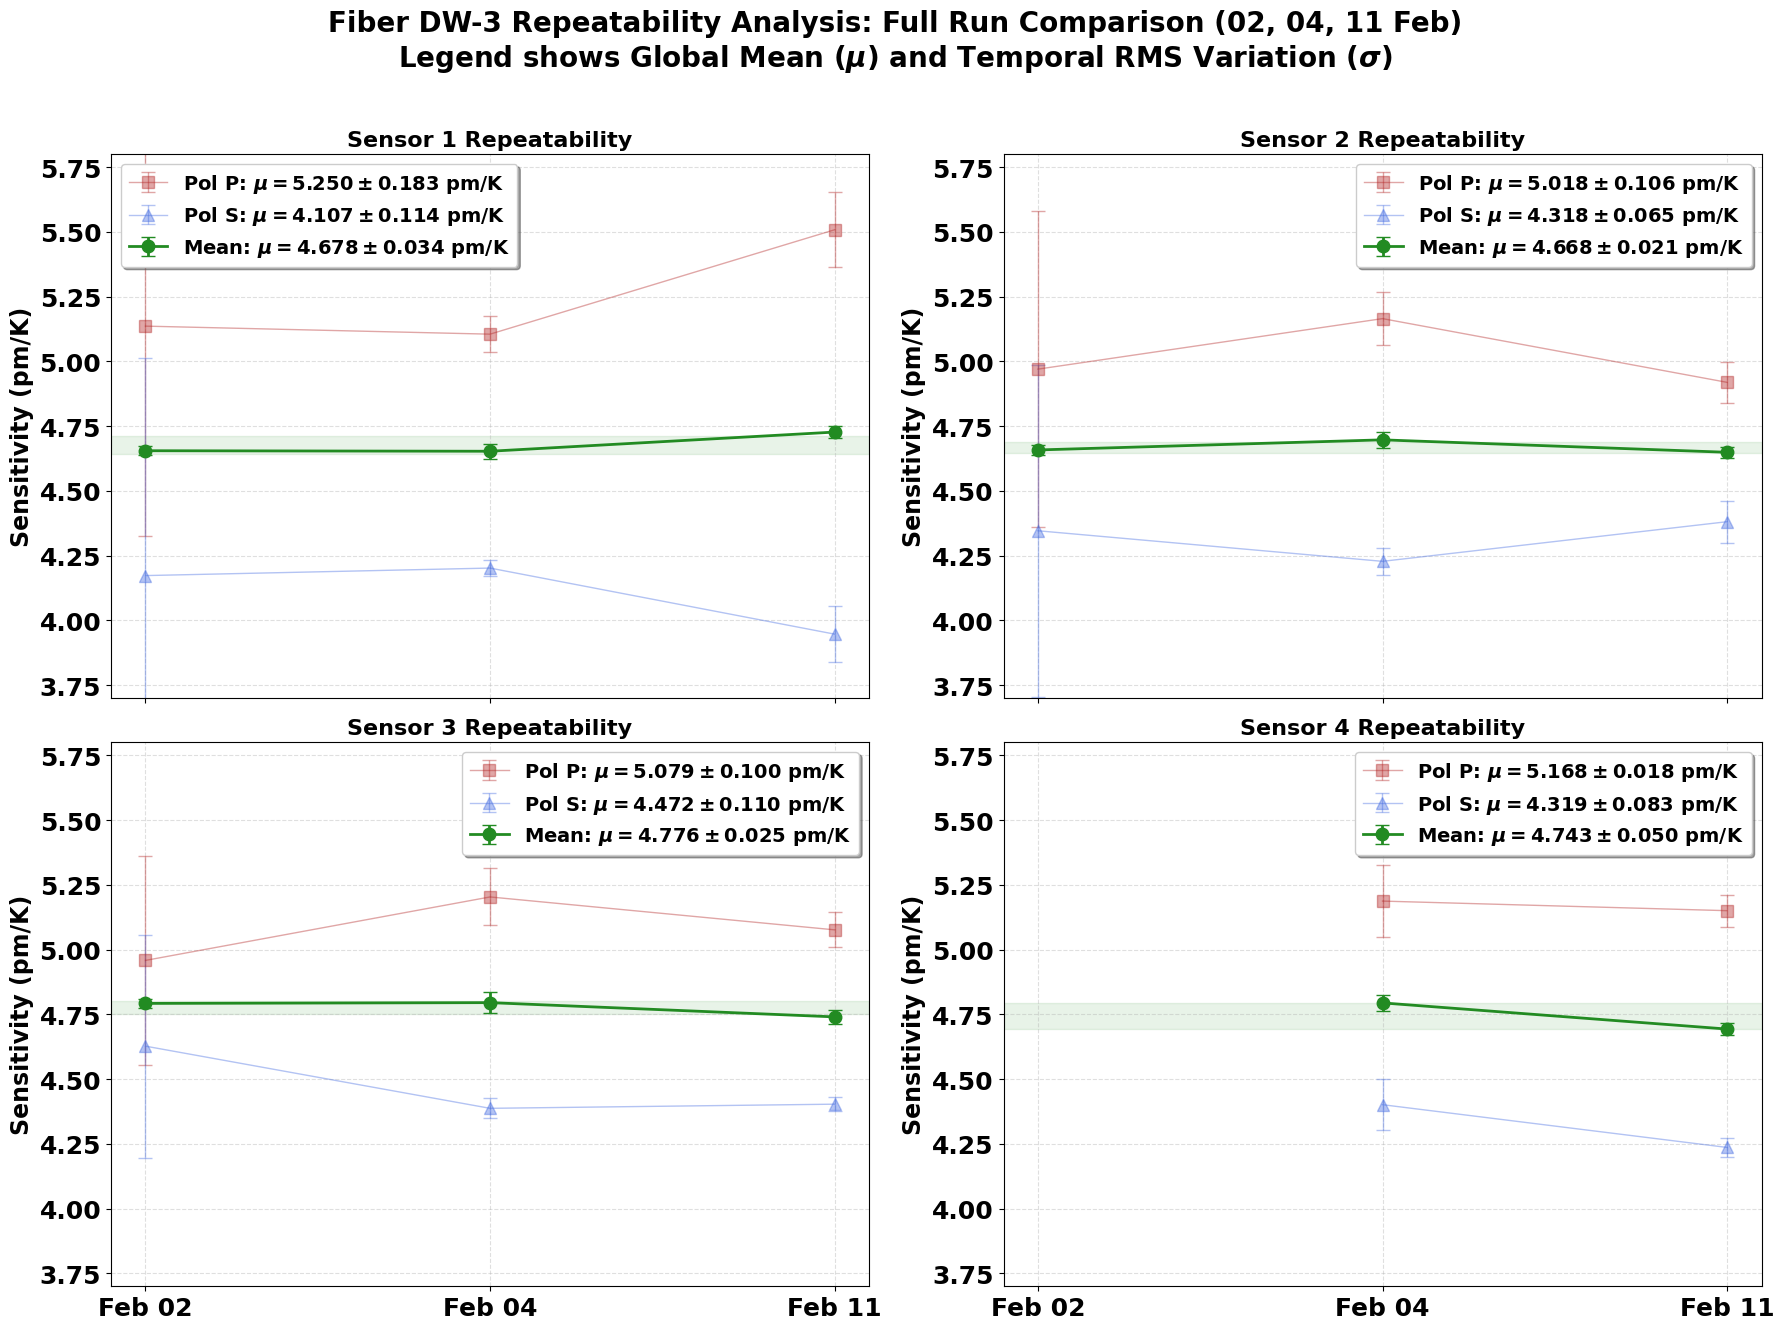

In [24]:
# ============================================================================
# FINAL REPEATABILITY PLOT: P, S, and Mean with Shaded Sigma Bands
# Fiber: DW-3 | Run 3 (11/02) | Statistics included in Legend
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

dates = ["Feb 02", "Feb 04", "Feb 11"]
x = np.arange(len(dates))

# Data dictionary (Values and Fit Errors in pm/K)
full_data = {
    "Sensor 1": {
        "Pol P": {"v": [5.136, 5.105, 5.508], "e": [0.810, 0.070, 0.145]},
        "Pol S": {"v": [4.173, 4.202, 3.947], "e": [0.841, 0.032, 0.109]},
        "Mean":  {"v": [4.655, 4.653, 4.727], "e": [0.018, 0.028, 0.024]}
    },
    "Sensor 2": {
        "Pol P": {"v": [4.970, 5.165, 4.919], "e": [0.610, 0.103, 0.080]},
        "Pol S": {"v": [4.346, 4.228, 4.381], "e": [0.641, 0.052, 0.081]},
        "Mean":  {"v": [4.658, 4.697, 4.649], "e": [0.018, 0.031, 0.022]}
    },
    "Sensor 3": {
        "Pol P": {"v": [4.958, 5.203, 5.076], "e": [0.405, 0.110, 0.067]},
        "Pol S": {"v": [4.627, 4.387, 4.403], "e": [0.431, 0.039, 0.026]},
        "Mean":  {"v": [4.792, 4.795, 4.740], "e": [0.018, 0.040, 0.028]}
    },
    "Sensor 4": {
        "Pol P": {"v": [np.nan, 5.187, 5.150], "e": [np.nan, 0.140, 0.062]},
        "Pol S": {"v": [np.nan, 4.401, 4.236], "e": [np.nan, 0.099, 0.036]},
        "Mean":  {"v": [np.nan, 4.794, 4.693], "e": [np.nan, 0.032, 0.023]}
    }
}

fig, axes = plt.subplots(2, 2, figsize=(18, 13), sharex=True)
axes = axes.flatten()

series_styles = {
    "Pol P": {"color": "firebrick", "marker": "s", "alpha_line": 0.4},
    "Pol S": {"color": "royalblue", "marker": "^", "alpha_line": 0.4},
    "Mean":  {"color": "forestgreen", "marker": "o", "alpha_line": 1.0}
}

for i, (sensor_name, series_dict) in enumerate(full_data.items()):
    ax = axes[i]
    
    for s_name, s_info in series_dict.items():
        v = np.array(s_info["v"])
        e = np.array(s_info["e"])
        valid = ~np.isnan(v)
        
        # Calculate Statistics for the Legend
        mu = np.nanmean(v)
        sigma = np.nanstd(v)
        
        # Plotting
        style = series_styles[s_name]
        label_str = f'{s_name}: $\mu={mu:.3f} \pm {sigma:.3f}$ pm/K'
        
        ax.errorbar(x[valid], v[valid], yerr=e[valid], 
                    fmt=style["marker"] + '-', color=style["color"],
                    capsize=5, markersize=9, linewidth=2 if s_name=="Mean" else 1,
                    alpha=style["alpha_line"], label=label_str)

        # Add Shading for the Mean series stability
        if s_name == "Mean":
            ax.axhspan(mu - sigma, mu + sigma, color=style["color"], alpha=0.1)

    # Subplot styling
    ax.set_title(f'{sensor_name} Repeatability', fontsize=16, fontweight='bold')
    ax.set_ylabel('Sensitivity (pm/K)', fontsize=17, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(dates, fontsize=17, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=14, loc='best', frameon=True, shadow=True)
    # Cambia 'labelsize' al número que prefieras (16 o 18 suele ir bien para informes)
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # Consistent Y-axis for comparison
    ax.set_ylim(3.7, 5.8)

plt.suptitle('Fiber DW-3 Repeatability Analysis: Full Run Comparison (02, 04, 11 Feb)\n'
             'Legend shows Global Mean ($\mu$) and Temporal RMS Variation ($\sigma$)', 
             fontsize=20, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()

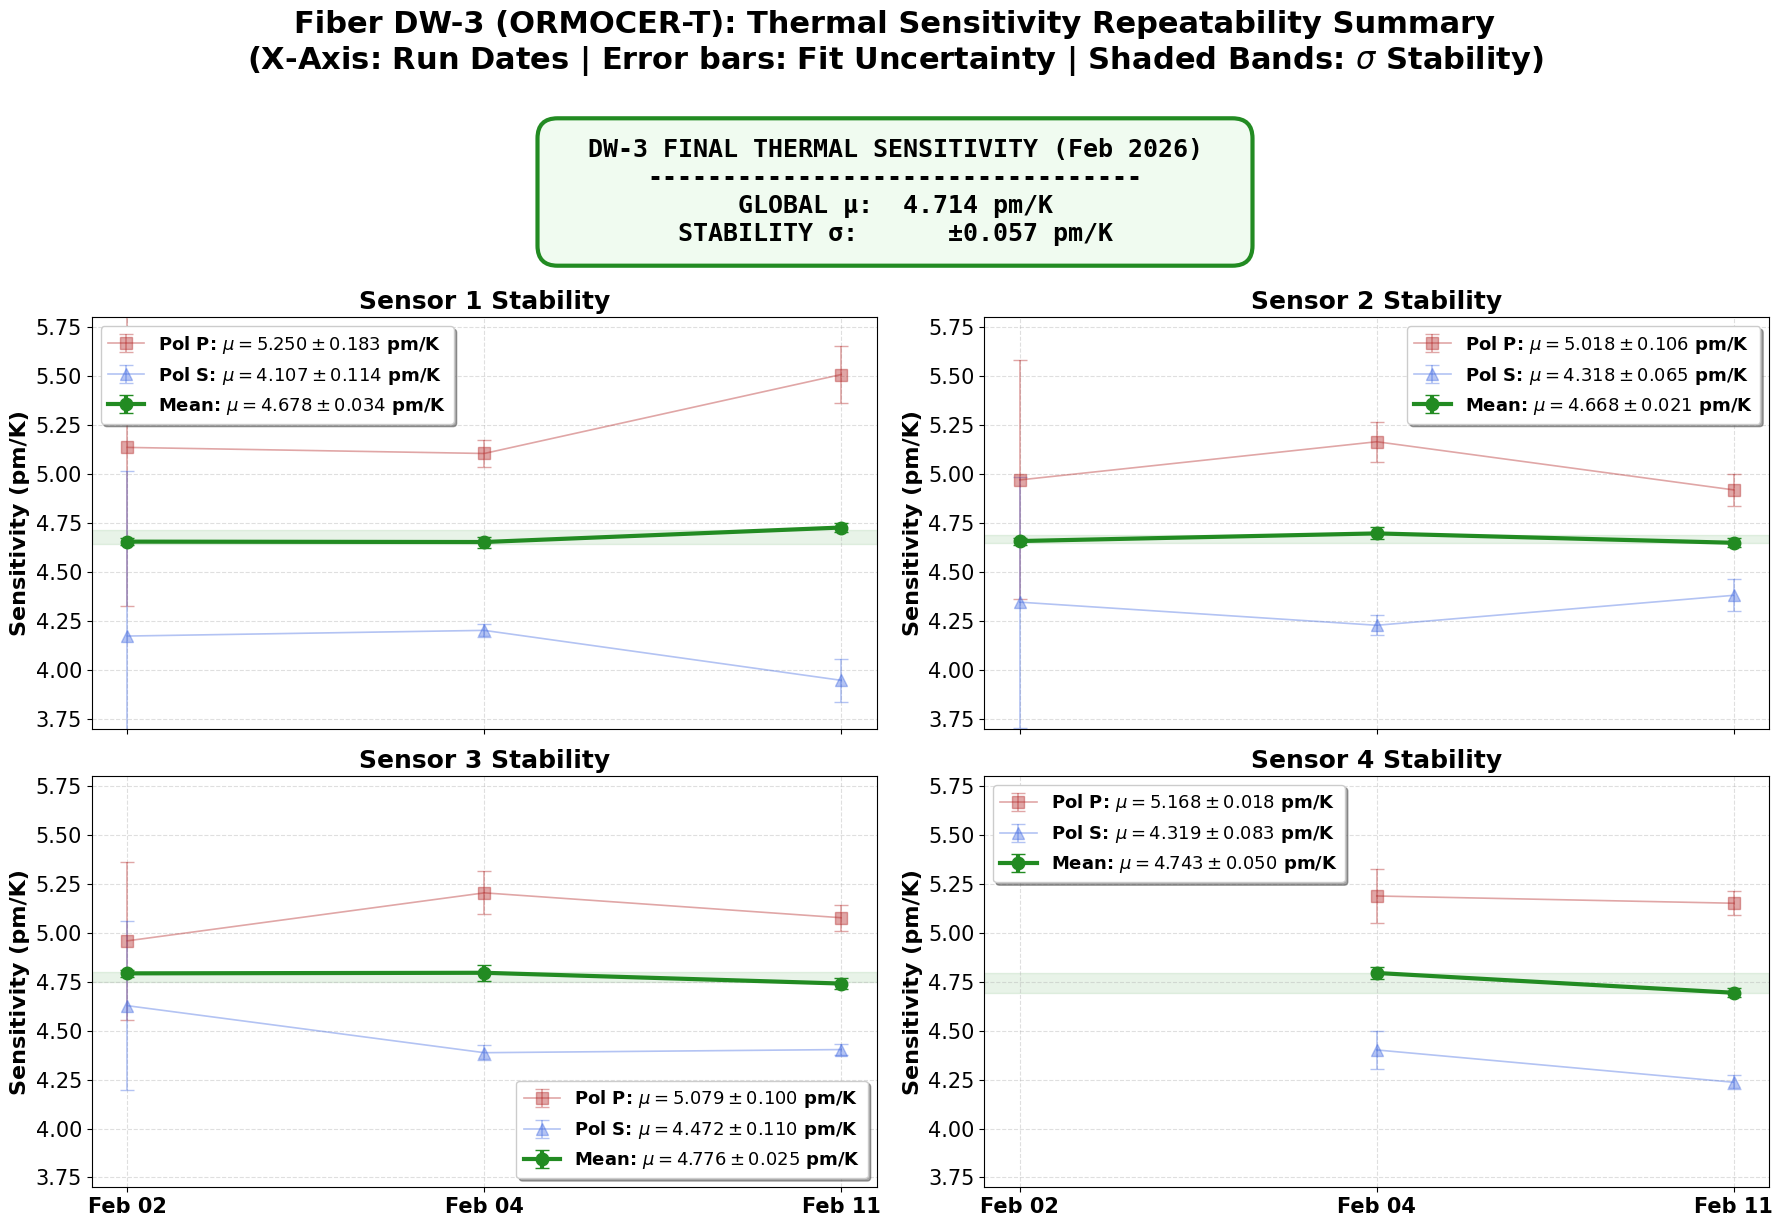

In [9]:
# ============================================================================
# FINAL REPEATABILITY PLOT: P, S, and Mean with Shaded Sigma Bands
# Fiber: DW-3 | GLOBAL KPI BOX INCLUDED
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

dates = ["Feb 02", "Feb 04", "Feb 11"]
x = np.arange(len(dates))

# Data dictionary (Values and Fit Errors in pm/K)
full_data = {
    "Sensor 1": {
        "Pol P": {"v": [5.136, 5.105, 5.508], "e": [0.810, 0.070, 0.145]},
        "Pol S": {"v": [4.173, 4.202, 3.947], "e": [0.841, 0.032, 0.109]},
        "Mean":  {"v": [4.655, 4.653, 4.727], "e": [0.018, 0.028, 0.024]}
    },
    "Sensor 2": {
        "Pol P": {"v": [4.970, 5.165, 4.919], "e": [0.610, 0.103, 0.080]},
        "Pol S": {"v": [4.346, 4.228, 4.381], "e": [0.641, 0.052, 0.081]},
        "Mean":  {"v": [4.658, 4.697, 4.649], "e": [0.018, 0.031, 0.022]}
    },
    "Sensor 3": {
        "Pol P": {"v": [4.958, 5.203, 5.076], "e": [0.405, 0.110, 0.067]},
        "Pol S": {"v": [4.627, 4.387, 4.403], "e": [0.431, 0.039, 0.026]},
        "Mean":  {"v": [4.792, 4.795, 4.740], "e": [0.018, 0.040, 0.028]}
    },
    "Sensor 4": {
        "Pol P": {"v": [np.nan, 5.187, 5.150], "e": [np.nan, 0.140, 0.062]},
        "Pol S": {"v": [np.nan, 4.401, 4.236], "e": [np.nan, 0.099, 0.036]},
        "Mean":  {"v": [np.nan, 4.794, 4.693], "e": [np.nan, 0.032, 0.023]}
    }
}

# ----------------------------------------------------------------------------
# AUTOMATIC GLOBAL KPI CALCULATION (DW-3 Network)
# ----------------------------------------------------------------------------
all_mean_values = []
for sensor, series in full_data.items():
    all_mean_values.extend(series["Mean"]["v"])

clean_means = [val for val in all_mean_values if not np.isnan(val)]
global_mu = np.mean(clean_means)
global_sigma = np.std(clean_means)

# 2. PLOT CONFIGURATION
fig, axes = plt.subplots(2, 2, figsize=(18, 13), sharex=True)
axes = axes.flatten()

series_styles = {
    "Pol P": {"color": "firebrick", "marker": "s", "alpha_line": 0.4},
    "Pol S": {"color": "royalblue", "marker": "^", "alpha_line": 0.4},
    "Mean":  {"color": "forestgreen", "marker": "o", "alpha_line": 1.0}
}

# 3. LOOP THROUGH SENSORS
for i, (sensor_name, series_dict) in enumerate(full_data.items()):
    ax = axes[i]
    
    for s_name, s_info in series_dict.items():
        v = np.array(s_info["v"])
        e = np.array(s_info["e"])
        valid = ~np.isnan(v)
        
        mu = np.nanmean(v)
        sigma = np.nanstd(v)
        
        style = series_styles[s_name]
        # Se añade pm/K al label
        label_str = f'{s_name}: $\mu={mu:.3f} \pm {sigma:.3f}$ pm/K'
        
        ax.errorbar(x[valid], v[valid], yerr=e[valid], 
                    fmt=style["marker"] + '-', color=style["color"],
                    capsize=5, markersize=9, linewidth=3 if s_name=="Mean" else 1.2,
                    alpha=style["alpha_line"], label=label_str)

        if s_name == "Mean":
            ax.axhspan(mu - sigma, mu + sigma, color=style["color"], alpha=0.1)

    ax.set_title(f'{sensor_name} Stability', fontsize=18, fontweight='bold')
    ax.set_ylabel('Sensitivity (pm/K)', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(dates, fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Leyenda en 'best' para no tapar datos y forzado de negrita
    leg = ax.legend(loc='best', frameon=True, shadow=True, fontsize=13)
    plt.setp(leg.get_texts(), fontweight='bold')
    
    ax.tick_params(axis='both', labelsize=15)
    ax.set_ylim(3.7, 5.8)

# ----------------------------------------------------------------------------
# GLOBAL KPI BOX (Fiber Verdict)
# ----------------------------------------------------------------------------
kpi_text = (
    f"  DW-3 FINAL THERMAL SENSITIVITY (Feb 2026)  \n"
    f"---------------------------------\n"
    f"GLOBAL μ:  {global_mu:.3f} pm/K\n"
    f"STABILITY σ:      ±{global_sigma:.3f} pm/K"
)

fig.text(0.5, 0.83, kpi_text, fontsize=18, fontweight='bold', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#F0FBF0', edgecolor='forestgreen', 
                  linewidth=3),
         ha='center', va='center', zorder=10)

plt.suptitle('Fiber DW-3 (ORMOCER-T): Thermal Sensitivity Repeatability Summary\n'
             r'(X-Axis: Run Dates | Error bars: Fit Uncertainty | Shaded Bands: $\sigma$ Stability)', 
             fontsize=22, y=0.97, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.83])
plt.show()

## 📝 Guía de Uso

### Pasos básicos:
1. **Celda 2**: Cambiar ruta del archivo ROOT (20260211.root)
2. **Celda 3**: Ajustar rango horario si es necesario (15:00-17:30)
3. **Celda 6.1**: Seleccionar RTD de referencia
4. **Celda 6.2**: Visualizar perfiles Temp/Presión-Wavelength para identificar plateaus
5. **Celda 6.3**: Definir plateaus manuales con intervalos temporales
6. **Ejecutar todo**: Run All

### Configuración:
- **RTD referencia**: Celda 6.1 → `rtd_ref_idx` (6 = RTD-6 "Cápsula")
- **Plateaus**: Celda 6.3 → editar `manual_plateaus` con intervalos estables
- **Rango temporal**: Celda 3 → `t_inicio`, `t_fin`

### Método de plateaus:
El análisis calcula sensibilidades usando **plateaus manuales basados en presión**:
1. Identificar intervalos donde presión es estable (visualizar en 6.2)
2. Definir intervalos temporales en formato "HH:MM" con presión aproximada (celda 6.3)
3. Calcular μ±σ de temperatura, presión y wavelength en cada plateau
4. Sensibilidad térmica = pendiente del ajuste lineal Temp vs Wavelength
5. Sensibilidad a presión = pendiente del ajuste lineal Presión vs Wavelength

### Output:
- **Sección 2**: Gráfico de presión y temperatura superpuestos
- **Sección 4**: Gráficos de temperatura (8 RTDs)
- **Sección 5**: Gráficos de wavelengths (FBG-1,2,3)
- **Sección 6.2**: Visualización Temp/Presión-Wavelength superpuesta
- **Sección 6.3-6.4**: Estadísticas de plateaus (μ±σ temperatura y presión)
- **Sección 6.5**: Gráficos de sensibilidad térmica con error bars y R²
- **Sección 6.6**: Gráficos de sensibilidad a presión con error bars y R²
- **Sección 8**: Resumen con sensibilidades en pm/K y pm/bar

### Ejemplo de plateaus (11/02/2026):
```python
manual_plateaus = [
    ("Plateau 1 (2.75 bar)", "15:56", "16:07"),
    ("Plateau 2 (2.4 bar)", "16:12", "16:21"),
    ("Plateau 3 (2.0 bar)", "16:26", "16:34"),
    ("Plateau 4 (1.5 bar)", "16:39", "16:52"),
    ("Plateau 5 (1.0 bar)", "16:57", "17:10"),
    ("Plateau 6", "17:10", "17:20"),
]
```

**Nota**: FBG-4 excluido por falla del sensor (status=0 en adquisición).

**Novedad**: En esta adquisición (11/02/2026) los datos de presión funcionan correctamente y se utilizan tanto para definir plateaus como para calcular sensibilidades a presión.

## 📊 **Plot: Espectro Individual en Tiempo Específico**

Visualiza el espectro completo de un sensor FBG en un instante temporal determinado. Útil para analizar la forma del pico, FWHM, y calidad de la medición.

In [25]:
from scipy.signal import find_peaks, peak_widths

# ============================================================================
# CONFIGURACIÓN: ESPECTRO INDIVIDUAL
# ============================================================================

# ⏰ Tiempo a visualizar (aprox. en el primer plateau)
TARGET_TIME = datetime.datetime(2026, 2, 11, 15, 15, 0)  # Ajusta según tu necesidad

# 🔍 Selección de sensor y polarización
# Estructura del archivo DW3: depende del tree 'spectrum' específico
# En este notebook los datos pueden tener diferentes estructuras según la adquisición

PLOT_SENSOR_IDX = 0   # Índice del sensor a visualizar
PLOT_POL_IDX = 0      # 0=P, 1=S
PLOT_PEAK_IDX = 0     # Si hay múltiples picos, cuál visualizar

POL_NAMES = {0: 'P', 1: 'S'}
PLOT_POL = POL_NAMES[PLOT_POL_IDX]

# ============================================================================
# PASO 1: Verificar estructura del tree 'spectrum' en el archivo ROOT
# ============================================================================

print("="*80)
print("📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (DW-3, 11/02/2026)")
print("="*80)

try:
    with uproot.open(filepath) as file:
        # Verificar que existe el tree 'spectrum'
        if 'spectrum' in file:
            spectrum_tree = file['spectrum']
            print(f"\n✅ Tree 'spectrum' encontrado")
            print(f"   Ramas disponibles: {spectrum_tree.keys()}")
            
            # Leer una muestra pequeña
            sample = spectrum_tree.arrays(library="np", entry_stop=1)
            
            print(f"\n📊 Estructura de datos:")
            for key in sample.keys():
                data = sample[key]
                if hasattr(data, 'shape'):
                    print(f"   '{key}': shape={data.shape}, dtype={data.dtype}")
                else:
                    print(f"   '{key}': {type(data)}")
            
            # Verificar estructura de 'wav' (espectros)
            if 'wav' in sample:
                wav_sample = sample['wav']
                if hasattr(wav_sample, 'shape'):
                    print(f"\n   Detalle de 'wav' (espectros completos):")
                    print(f"      Shape: {wav_sample.shape}")
                    if wav_sample.ndim == 4:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, dim2={wav_sample.shape[2]}, n_points={wav_sample.shape[3]})")
                    elif wav_sample.ndim == 3:
                        print(f"      → Dimensiones: (n_entries={wav_sample.shape[0]}, "
                              f"dim1={wav_sample.shape[1]}, n_points={wav_sample.shape[2]})")
                    elif wav_sample.ndim == 2:
                        print(f"      → Dimensiones: (dim0={wav_sample.shape[0]}, n_points={wav_sample.shape[1]})")
            
            # Verificar timestamps
            if 't' in sample:
                t_sample = sample['t']
                if hasattr(t_sample, 'shape'):
                    print(f"\n   ⏰ Timestamps ('t'):")
                    print(f"      Shape: {t_sample.shape}")
                    if len(t_sample) > 0:
                        print(f"      Primeros valores: {t_sample.flat[:3]}")
                    else:
                        print(f"      (vacío - se usarán timestamps de 'peak')")
        else:
            print(f"\n❌ Tree 'spectrum' NO encontrado en el archivo ROOT")
            print(f"   Trees disponibles: {file.keys()}")

except Exception as e:
    print(f"\n❌ Error verificando estructura: {e}")

print("="*80)

# ============================================================================
# PASO 2: Cargar datos y encontrar el evento más cercano al tiempo objetivo
# ============================================================================

print("\n🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO")
print("="*80)

wav_data = None
spectrum = None
center_idx = None
closest_time = None

try:
    with uproot.open(filepath) as file:
        if 'spectrum' not in file:
            print("❌ No hay tree 'spectrum' disponible en este archivo")
        else:
            spectrum_tree = file['spectrum']
            
            # Intentar obtener timestamps - pueden estar en spectrum o en peak
            timestamps_raw = None
            
            try:
                timestamps_raw = spectrum_tree['t'].array(library="np")
                if len(timestamps_raw) == 0:
                    timestamps_raw = None
                else:
                    print("   ✅ Usando timestamps de 'spectrum.t'")
            except:
                pass
            
            if timestamps_raw is None:
                print("   ℹ️  'spectrum.t' vacío o no disponible, usando timestamps de 'peak.t'")
                if 'peak' in file:
                    timestamps_raw = file['peak']['t'].array(library="np")
                else:
                    raise ValueError("No hay timestamps disponibles")
            
            # Procesar según estructura (puede ser 1D o 2D)
            if timestamps_raw.ndim == 2:
                timestamps = timestamps_raw[:, 0]
                print(f"   Timestamps shape: {timestamps_raw.shape} → usando columna 0")
            elif timestamps_raw.ndim == 1:
                timestamps = timestamps_raw
                print(f"   Timestamps shape: {timestamps_raw.shape}")
            else:
                print(f"   ⚠️  Estructura inesperada de timestamps: shape={timestamps_raw.shape}")
                timestamps = timestamps_raw.flatten()
            
            if len(timestamps) == 0:
                raise ValueError("No hay timestamps válidos después del procesamiento")
            
            # Convertir TARGET_TIME a timestamp Unix
            target_timestamp = TARGET_TIME.timestamp()
            
            # Encontrar índice más cercano
            time_diffs = np.abs(timestamps - target_timestamp)
            closest_idx_time = np.argmin(time_diffs)
            closest_timestamp = timestamps[closest_idx_time]
            closest_time = datetime.datetime.fromtimestamp(closest_timestamp)
            
            print(f"   Tiempo objetivo:     {TARGET_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Tiempo más cercano:  {closest_time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Diferencia:          {abs(closest_timestamp - target_timestamp):.1f} segundos")
            print(f"   Índice del evento:   {closest_idx_time}")
            
            # Cargar el evento específico del tree 'spectrum'
            wav_data_raw = spectrum_tree['wav'].array(library="np", entry_start=closest_idx_time, entry_stop=closest_idx_time+1)
            
            print(f"\n📊 Datos cargados del tree 'spectrum':")
            print(f"   Shape raw: {wav_data_raw.shape}")
            
            # Verificar si hay datos
            if wav_data_raw.size == 0:
                print(f"\n   ⚠️  El tree 'spectrum' contiene datos pero están vacíos")
                print(f"       Puede que los datos espectrales no estén disponibles en este archivo")
                raise ValueError("Tree 'spectrum' sin datos útiles")
            
            # Procesar según estructura
            if wav_data_raw.ndim == 4:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 4D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 3:
                wav_data = wav_data_raw[0]
                print(f"   → Estructura 3D detectada, extrayendo primera entrada: {wav_data.shape}")
            elif wav_data_raw.ndim == 2:
                wav_data = wav_data_raw
                print(f"   → Estructura 2D detectada: {wav_data.shape}")
            else:
                wav_data = wav_data_raw
                print(f"   → Estructura {wav_data_raw.ndim}D, usando como está")
            
            print(f"\n📊 Datos del evento listo para procesar:")
            print(f"   Shape final: {wav_data.shape}")
            print(f"   Tamaño total: {wav_data.size} elementos")
                
except Exception as e:
    print(f"\n❌ Error cargando eventos: {e}")
    import traceback
    traceback.print_exc()
    wav_data = None

# ============================================================================
# PASO 3: Extraer y visualizar el espectro seleccionado
# ============================================================================

if wav_data is not None and closest_time is not None:
    print(f"\n📈 EXTRAYENDO ESPECTRO")
    print("="*80)
    
    print(f"   Sensor Index:  {PLOT_SENSOR_IDX}")
    print(f"   Polarización:  {PLOT_POL}")
    print(f"   Tiempo:        {closest_time.strftime('%H:%M:%S')}")
    
    # Extraer espectro según estructura
    try:
        # Intentar diferentes estructuras
        if wav_data.ndim == 3:
            # Probar (sensores, pol, puntos)
            spectrum_full = wav_data[PLOT_SENSOR_IDX, PLOT_POL_IDX, :]
            print(f"   ✅ Espectro extraído (estructura 3D: sensor x pol x puntos)")
        elif wav_data.ndim == 2:
            # Probar (canales, puntos)
            ch = PLOT_SENSOR_IDX * 2 + PLOT_POL_IDX
            if ch < wav_data.shape[0]:
                spectrum_full = wav_data[ch, :]
                print(f"   ✅ Espectro extraído (estructura 2D, canal {ch})")
            else:
                # Si no hay suficientes canales, usar el índice como está
                spectrum_full = wav_data[PLOT_SENSOR_IDX, :]
                print(f"   ✅ Espectro extraído (estructura 2D, usando índice {PLOT_SENSOR_IDX})")
        elif wav_data.ndim == 1:
            spectrum_full = wav_data
            print(f"   ✅ Espectro 1D, usando directamente")
        else:
            raise ValueError(f"Estructura inesperada: {wav_data.ndim}D")
        
        # Diagnosticar
        print(f"   Puntos en espectro: {len(spectrum_full)}")
        print(f"   Rango de amplitud: [{np.nanmin(spectrum_full):.6e}, {np.nanmax(spectrum_full):.6e}]")
        n_nans = np.sum(np.isnan(spectrum_full))
        print(f"   NaN values: {n_nans}")
        
        # Detectar picos
        all_peaks, _ = find_peaks(spectrum_full, height=100, distance=500)
        print(f"\n   🔍 Picos detectados: {len(all_peaks)}")
        for i, peak_pos in enumerate(all_peaks[:5]):  # Mostrar primeros 5
            print(f"      Pico #{i}: posición {peak_pos}, amplitud {spectrum_full[peak_pos]:.1f}")
        if len(all_peaks) > 5:
            print(f"      ... ({len(all_peaks)-5} picos más)")
        
        # Seleccionar pico
        if len(all_peaks) > PLOT_PEAK_IDX:
            center_idx = all_peaks[PLOT_PEAK_IDX]
            print(f"\n   ✅ Pico #{PLOT_PEAK_IDX} seleccionado: posición {center_idx}")
        else:
            if len(all_peaks) > 0:
                center_idx = all_peaks[0]
                print(f"\n   ⚠️  PLOT_PEAK_IDX={PLOT_PEAK_IDX} fuera de rango. Usando primer pico.")
            else:
                center_idx = len(spectrum_full) // 2
                print(f"\n   ⚠️  No hay picos detectados. Usando centro del espectro.")
        
        spectrum = spectrum_full
        
    except Exception as e:
        print(f"   ❌ Error extrayendo espectro: {e}")
        import traceback
        traceback.print_exc()
        spectrum = None
        center_idx = None

print("="*80)

# ============================================================================
# PASO 4: Análisis y plotting del pico
# ============================================================================

if spectrum is not None and center_idx is not None and len(spectrum) > 0:
    print("\n🔬 ANALIZANDO PICO SELECCIONADO")
    print("="*80)
    
    print(f"   ✅ Pico en posición {center_idx} (amplitud: {spectrum[center_idx]:.1f})")
    
    # Calcular FWHM
    try:
        results_half = peak_widths(spectrum, [center_idx], rel_height=0.5)
        fwhm_points = results_half[0][0]
        fwhm_pm = fwhm_points * 1  # Asumiendo 1 pm por punto
        print(f"   📏 FWHM: {fwhm_pm:.1f} pm ({fwhm_points:.1f} puntos)")
    except:
        print(f"   ⚠️  No se pudo calcular FWHM")
        fwhm_points = 50
        fwhm_pm = 50
        results_half = None
    
    # Definir ventana alrededor del pico
    window = int(fwhm_points * 2)
    start_idx = max(center_idx - window, 0)
    end_idx = min(center_idx + window, len(spectrum))
    
    print(f"   📐 Ventana de visualización: índices [{start_idx}, {end_idx}]")
    
    x_pm = np.arange(start_idx, end_idx)
    y = spectrum[start_idx:end_idx]
    
    print("="*80)
    
    # ============================================================================
    # PLOT
    # ============================================================================
    
    fiber_name = f"DW-3 Sensor-{PLOT_SENSOR_IDX} ({PLOT_POL})"
    
    plt.figure(figsize=(11, 7))
    plt.plot(x_pm, y, linewidth=1.5, label=f"Pico #{PLOT_PEAK_IDX} (FWHM ≈ {fwhm_pm:.1f} pm)", color='#1f77b4')
    
    # Marcar FWHM
    if results_half is not None:
        plt.hlines(results_half[1], results_half[2], results_half[3], 
                   color='red', linestyle='--', linewidth=2.5, label='FWHM (-3dB)')
        plt.plot([results_half[2], results_half[3]], results_half[1], 'ro', markersize=8)
    
    plt.xlabel("Índice de Punto de Wavelength", fontsize=12, fontweight='bold')
    plt.ylabel("Amplitud (V)", fontsize=12, fontweight='bold')
    if closest_time is not None:
        plt.title(f"{fiber_name} - Espectro @ {closest_time.strftime('%H:%M:%S')}\n(11/02/2026)", 
                  fontsize=14, fontweight='bold')
    else:
        plt.title(f"{fiber_name} - Espectro\n(11/02/2026)", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Plot generado exitosamente")
else:
    print("\n❌ No se pudo generar el plot (espectro vacío o inválido)")

📂 VERIFICANDO ESTRUCTURA DEL TREE DE ESPECTROS (DW-3, 11/02/2026)

❌ Tree 'spectrum' NO encontrado en el archivo ROOT
   Trees disponibles: ['peak;5', 'press;3', 'temp;3']

🔍 BUSCANDO EVENTO MÁS CERCANO AL TIEMPO OBJETIVO
❌ No hay tree 'spectrum' disponible en este archivo

❌ No se pudo generar el plot (espectro vacío o inválido)
